In [1]:
a='Mar.mT19_7-23-3-2.genes.results'
b=a.split('.')[1]
print(b)


mT19_7-23-3-2


In [1]:
!pwd

/Users/hc284/Documents/_0taihuXomicsMicrobiome


In [64]:
import pandas as pd
import plotly.graph_objects as go

df=pd.read_csv('water_chemistry.csv')
print(df.columns)
df['Date']=df['SampleID'].str.split('_').str[1].str.rsplit('.', n=1).str[0]
df['Site'] = ['A','B','C'] * 6
df = df[['Date','Site', 'pH',  'DTN', 'NH4_N', 'NO3_N',
       'NO2_N', 'DTP', 'Pi']]
print(df)

Index(['SampleID', 'T', 'pH', 'Chl', 'PC', 'DO', 'DTN', 'NH4_N', 'NO3_N',
       'NO2_N', 'DTP', 'Pi', 'MC', 'PC/Chl', 'MC/PC', 'DTN/DTP'],
      dtype='object')
     Date Site   pH     DTN   NH4_N   NO3_N   NO2_N     DTP        Pi
0   06.15    A  8.0  1.2535  0.1089  0.3434  0.0263  0.6996  0.670196
1   06.15    B  6.9  1.5372  0.1644  0.6693  0.0653  0.2239  0.190599
2   06.15    C  8.0  0.6511  0.0523  0.0548  0.0017  0.9319  0.504858
3   07.23    A  8.0  1.1070  0.1444  0.2170  0.0290  0.3969  0.363959
4   07.23    B  8.1  0.9696  0.0711  0.2294  0.0303  0.1518  0.126294
5   07.23    C  8.0  0.7874  0.0666  0.1994  0.1291  0.1271  0.088537
6   09.10    A  7.8  1.5795  0.0543  0.8916  0.1132  0.1704  0.144667
7   09.10    B  7.2  1.5885  0.2868  0.7421  0.0722  0.2181  0.190232
8   09.10    C  8.0  0.5851  0.0563  0.0297  0.0017  0.1327  0.101316
9   09.29    A  8.0  0.9392  0.0741  0.2228  0.0282  0.1250  0.109069
10  09.29    B  8.1  0.8116  0.0431  0.1754  0.0221  0.2720  0.25776

In [1]:
import pandas as pd
import plotly.graph_objects as go

# Sample Data
df = pd.DataFrame({
    'Date': ['06.15', '06.15', '06.15', '07.23', '07.23', '07.23',
             '09.10', '09.10', '09.10', '09.29', '09.29', '09.29',
             '11.3', '11.3', '11.3', '12.4', '12.4', '12.4'],
    'Site': ['A', 'B', 'C'] * 6,
    'pH': [8.0, 6.9, 8.0, 8.0, 8.1, 8.0, 7.8, 7.2, 8.0, 8.0, 8.1, 7.8, 7.8, 7.6, 7.4, 7.0, 7.1, 7.3],
    'DTN': [1.2535, 1.5372, 0.6511, 1.1070, 0.9696, 0.7874, 1.5795, 1.5885, 0.5851, 0.9392, 0.8116, 0.7493, 1.4395, 1.5446, 1.6728, 2.1611, 2.2785, 0.8297],
    'NH4_N': [0.1089, 0.1644, 0.0523, 0.1444, 0.0711, 0.0666, 0.0543, 0.2868, 0.0563, 0.0741, 0.0431, 0.0630, 0.0270, 0.0288, 0.1737, 0.4183, 0.5160, 0.1424],
    'NO3_N': [0.3434, 0.6693, 0.0548, 0.2170, 0.2294, 0.1994, 0.8916, 0.7421, 0.0297, 0.2228, 0.1754, 0.0314, 0.8149, 0.8713, 0.9171, 1.3390, 1.1494, 0.1988],
    'NO2_N': [0.0263, 0.0653, 0.0017, 0.0290, 0.0303, 0.1291, 0.1132, 0.0722, 0.0017, 0.0282, 0.0221, 0.0043, 0.0180, 0.0271, 0.0286, 0.0368, 0.0299, 0.0054],
    'DTP': [0.6996, 0.2239, 0.9319, 0.3969, 0.1518, 0.1271, 0.1704, 0.2181, 0.1327, 0.1250, 0.2720, 0.1264, 0.1034, 0.0903, 0.0785, 0.1142, 0.1023, 0.0651],
    'Pi': [0.670196, 0.190599, 0.504858, 0.363959, 0.126294, 0.088537, 0.144667, 0.190232, 0.101316, 0.109069, 0.257768, 0.088292, 0.040549, 0.021742, 0.027671, 0.063463, 0.055632, 0.038246]
})

# Convert Date to ordered numeric index
date_order = ['06.15', '07.23', '09.10', '09.29', '11.3', '12.4']
df['Date'] = pd.Categorical(df['Date'], categories=date_order, ordered=True)
df['DateIndex'] = df['Date'].cat.codes

# Convert Site to numeric index
site_map = {'A': 0, 'B': 1, 'C': 2}
df['SiteIndex'] = df['Site'].map(site_map)

# Variables to plot and colors
variables = ['pH', 'DTN', 'NH4_N', 'NO3_N', 'NO2_N', 'DTP', 'Pi']
colors = ['red', 'green', 'blue', 'orange', 'purple', 'cyan', 'magenta']

# Create plot
fig = go.Figure()

# Add traces for each variable and site (only show legend once per variable)
for var_idx, (var, color) in enumerate(zip(variables, colors)):
    for site_idx, site in enumerate(df['Site'].unique()):
        subset = df[df['Site'] == site]
        fig.add_trace(go.Scatter3d(
            x=subset['DateIndex'],
            y=[site_map[site]] * len(subset),
            z=subset[var],
            mode='lines+markers',
            name=var if site_idx == 0 else None,  # only label once per variable
            showlegend=(site_idx == 0),
            line=dict(color=color),
            marker=dict(size=4)
        ))

# Customize axes and layout
fig.update_layout(
    title="3D Line Plot of Water Chemistry Variables by Site and Time",
    scene=dict(
        xaxis=dict(title='Date', tickvals=list(range(len(date_order))), ticktext=date_order),
        yaxis=dict(title='Site', tickvals=[0, 1, 2], ticktext=['A', 'B', 'C']),
        zaxis=dict(title='Measurement Value')
    ),
    legend=dict(itemsizing='constant'),
    height=800
)

# Save and show
fig.write_html('metadata_NPplots.html')
fig.show()


In [2]:
import pandas as pd
import plotly.graph_objects as go

# Create the DataFrame
df = pd.DataFrame({
    'Date': ['06.15', '06.15', '06.15', '07.23', '07.23', '07.23',
             '09.10', '09.10', '09.10', '09.29', '09.29', '09.29',
             '11.3', '11.3', '11.3', '12.4', '12.4', '12.4'],
    'Site': ['A', 'B', 'C'] * 6,
    'MC': [25.456808, 14.658668, 12.065090, 2.557642, 1.984582, 2.229247,
           4.102333, 4.412242, 3.521661, 69.079020, 74.135430, 60.678855,
           25.271950, 25.978760, 4.294802, 2.595701, 1.187480, 22.988410],
    'PC': [7.34, 0.76, 3.09, 7.88, 4.59, 2.40, 2.21, 1.11, 3.23,
           11.26, 2.56, 12.58, 4.20, 4.70, 1.15, 0.05, 0.16, 0.33],
    'T': [25.520, 26.573, 27.718, 32.481, 33.133, 30.747,
          29.327, 31.238, 32.182, 26.763, 26.465, 27.457,
          19.376, 19.916, 19.931, 9.527, 10.146, 9.308]
})

# Convert Date to ordered category and numeric index
date_order = ['06.15', '07.23', '09.10', '09.29', '11.3', '12.4']
df['Date'] = pd.Categorical(df['Date'], categories=date_order, ordered=True)
df['DateIndex'] = df['Date'].cat.codes

# Map site letters to numbers
site_map = {'A': 0, 'B': 1, 'C': 2}
df['SiteIndex'] = df['Site'].map(site_map)

# Create 3D plot
fig = go.Figure()

# Plot each variable with different color (legend only once per variable)
colors = {'MC': 'blue', 'PC': 'cyan', 'T': 'red'}

for var_idx, var in enumerate(['MC', 'PC', 'T']):
    for site_idx, site in enumerate(df['Site'].unique()):
        subset = df[df['Site'] == site]
        fig.add_trace(go.Scatter3d(
            x=subset['DateIndex'],
            y=[site_map[site]] * len(subset),
            z=subset[var],
            mode='lines+markers',
            name=var if site_idx == 0 else None,
            showlegend=(site_idx == 0),
            line=dict(color=colors[var]),
            marker=dict(size=4)
        ))

# Add horizontal plane at z=26
x_range = df['DateIndex'].unique()
y_range = list(site_map.values())
plane_x, plane_y = [], []
for x in x_range:
    for y in y_range:
        plane_x.append(x)
        plane_y.append(y)

fig.add_trace(go.Scatter3d(
    x=plane_x,
    y=plane_y * len(x_range),
    z=[26] * len(plane_x),
    mode='markers',
    marker=dict(size=0.1, color='gray'),
    name='Z = 26 Plane',
    showlegend=True
))

# Layout settings
fig.update_layout(
    title='3D Plot of MC, PC, and T Across Sites and Dates',
    scene=dict(
        xaxis=dict(title='Date', tickvals=list(range(len(date_order))), ticktext=date_order),
        yaxis=dict(title='Site', tickvals=[0, 1, 2], ticktext=['A', 'B', 'C']),
        zaxis=dict(title='Value')
    ),
    height=800
)

# Save and show
fig.write_html('metada_3D_MCPC.html')
fig.show()


In [3]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Step 1: Your DataFrame
df = pd.DataFrame({
    'Date': ['06.15', '06.15', '06.15', '07.23', '07.23', '07.23',
             '09.10', '09.10', '09.10', '09.29', '09.29', '09.29',
             '11.3', '11.3', '11.3', '12.4', '12.4', '12.4'],
    'Site': ['A', 'B', 'C'] * 6,
    'T': [25.520, 26.573, 27.718, 32.481, 33.133, 30.747,
          29.327, 31.238, 32.182, 26.763, 26.465, 27.457,
          19.376, 19.916, 19.931, 9.527, 10.146, 9.308],
    'Chl': [10.85, 4.45, 6.19, 7.93, 7.92, 9.60,
            8.20, 8.56, 11.19, 10.10, 8.63, 16.76,
            3.40, 10.63, 14.01, 0.39, 1.19, 2.33],
    'PC': [7.34, 0.76, 3.09, 7.88, 4.59, 2.40,
           2.21, 1.11, 3.23, 11.26, 2.56, 12.58,
           4.20, 4.70, 1.15, 0.05, 0.16, 0.33]
})

# Step 2: Convert Timepoints to numeric index
unique_times = df['Date'].unique()
time_map = {t: i for i, t in enumerate(unique_times)}
df['TimeIndex'] = df['Date'].map(time_map)

# Step 3: Map Sites to numeric Y levels
site_map = {s: i for i, s in enumerate(sorted(df['Site'].unique()))}
df['Site_Y'] = df['Site'].map(site_map)

# Step 4: Plot using Plotly
fig = go.Figure()

# Colors for variables
colors = {'T': 'red', 'Chl': 'green', 'PC': 'cyan'}

# Add lines for each variable at each site (show legend only once per variable)
for var_idx, var in enumerate(['T', 'Chl', 'PC']):
    for site_idx, site in enumerate(df['Site'].unique()):
        data_site = df[df['Site'] == site]
        fig.add_trace(go.Scatter3d(
            x=data_site['TimeIndex'],
            y=[site_map[site]] * len(data_site),
            z=data_site[var],
            mode='lines+markers',
            name=var if site_idx == 0 else None,
            showlegend=(site_idx == 0),
            line=dict(color=colors[var]),
            marker=dict(size=4)
        ))

# Step 5: Add Z=17 horizontal plane
x_vals = np.linspace(df['TimeIndex'].min(), df['TimeIndex'].max(), 10)
y_vals = np.linspace(min(site_map.values()), max(site_map.values()), 10)
x_mesh, y_mesh = np.meshgrid(x_vals, y_vals)
z_plane = np.full_like(x_mesh, 17)

fig.add_trace(go.Surface(
    x=x_mesh,
    y=y_mesh,
    z=z_plane,
    showscale=False,
    opacity=0.3,
    colorscale=[[0, 'gray'], [1, 'gray']],
    name='Z=17 Plane',
    showlegend=True
))

# Step 6: Final layout
fig.update_layout(
    title="3D Plot of Growth Variables Over Time and Site",
    scene=dict(
        xaxis_title="Date",
        xaxis=dict(
            tickvals=list(time_map.values()),
            ticktext=list(time_map.keys())
        ),
        yaxis_title="Site",
        yaxis=dict(
            tickvals=list(site_map.values()),
            ticktext=list(site_map.keys())
        ),
        zaxis_title="Value"
    ),
    height=700
)

fig.write_html("T_Chl-PC_3Dplot.html")
fig.show()


In [ ]:
import pandas as pd
import re
from collections import defaultdict 

def process_file(filename):
    df = pd.read_csv(filename, sep='\t')
    #df = pd.read_csv('./kaiju/kaiju_equalR4m_species_abundance.tsv', sep='\t')
    print(df.columns)
    # all taxa must have at least 10 reads
    df = df[df['reads'] >10]
    df = df[~df['taxon_name'].str.startswith(('unclassified','cannot be assigned'))]
    top_taxa = df['taxon_name'].str.split(';').str[0].unique()
    print(top_taxa)
    # summarize the total number of taxa in each sample over time
    files = df['file'].unique()
    df_sorted = pd.DataFrame({'taxon_name' : df['taxon_name'].unique()})
    for ifile in files:
        filename = "_".join(ifile.split("_")[:2])
        filename = re.sub(r'_(?=[679]\b)', r'_0', filename)
        tdf = df[df['file'] ==ifile].copy()
        tdf = tdf[['taxon_name', 'percent']]
        tdf.columns = ['taxon_name', filename]
        df_sorted = pd.merge(df_sorted, tdf, how='outer', on='taxon_name')
    # set NaN values to 0
    df_sorted = df_sorted.fillna(0)
    # sort columns and remove all 0 abundance taxa
    df_sorted = df_sorted.loc[(df_sorted.iloc[:, 1:] != 0).any(axis=1)]
    # sort the dataframe by the first column (taxon_name)
    cols = df_sorted.columns.tolist()
    df_sorted = df_sorted[[cols[0]] + sorted(cols[1:])]
    return df_sorted

#df = process_file('./kaiju/kaiju_eqR4mAbund_genus.tsv')
#df.to_csv('kaiju_eqR4m_totalNum_genus.tsv', sep='\t', index=False)

#df = process_file('./kaiju/kaiju_eqR4mAbund_species.tsv')
#df.to_csv('kaiju_eqR4m_totalNum_species.tsv', sep='\t', index=False)

Index(['file', 'percent', 'reads', 'taxon_id', 'taxon_name'], dtype='object')
['Bacteria' 'Eukaryota' 'Archaea' 'Viruses']


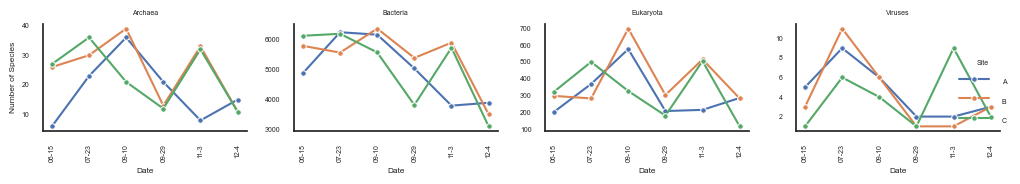

In [2]:
"""
Draw the number of species for four domains: 
Archaea, Bacteria, Eukaryota, and Viruses over time and by site.
"""

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ===== Parameters for font sizes =====
label_fontsize = 6
tick_fontsize = 5
title_fontsize = 5
legend_fontsize = 5

# ===== Load data =====
df = pd.read_csv('kaiju_eqR4m_totalNum_species.tsv', sep='\t')

# Extract Domain and Species
df['Domain'] = df['taxon_name'].str.split(';').str[0]
df['Species'] = df['taxon_name'].str.rsplit(';', n=2).str[-2]

# Keep only abundance columns
abundance_cols = df.columns[1:-2]

# Melt to long format
df_long = df.melt(
    id_vars=['Domain', 'Species'], 
    value_vars=abundance_cols,
    var_name='Sample', value_name='Abundance'
)

# Keep only species with abundance > 0
df_long = df_long[df_long['Abundance'] > 0]

# Extract Date (timepoint) and Site from Sample
df_long['Date'] = df_long['Sample'].str.rsplit('-', n=1).str[0].str.replace('mG19_', '', regex=False)
df_long['Site'] = df_long['Sample'].str.rsplit('-', n=1).str[1].map({'1':'A','2':'B','3':'C'})

# Count unique species per Domain × Date × Site
species_counts = (
    df_long.groupby(['Domain', 'Date', 'Site'])['Species']
    .nunique()
    .reset_index(name='NumSpecies')
)

# ===== Plotting =====
sns.set(style="white")
g = sns.FacetGrid(
    species_counts, col="Domain", hue="Site",
    col_wrap=4, height=2, aspect=1.2, sharey=False
)

g.map(sns.lineplot, "Date", "NumSpecies", marker="o", markersize=4)

# Add legend and adjust font sizes
legend = g.add_legend(title="Site")
for text in legend.legend.texts:
    text.set_fontsize(legend_fontsize)
legend.legend.get_title().set_fontsize(legend_fontsize)

# Axis titles
g.set_titles("{col_name}", size=title_fontsize)
g.set_axis_labels("Date", "Number of Species")
for ax in g.axes.flatten():
    ax.set_xlabel(ax.get_xlabel(), fontsize=label_fontsize)
    ax.set_ylabel(ax.get_ylabel(), fontsize=label_fontsize)
    ax.tick_params(axis='x', rotation=90, labelsize=tick_fontsize)
    ax.tick_params(axis='y', labelsize=tick_fontsize)

plt.tight_layout()
plt.savefig('NumSpecies_4domains_bySiteDate.svg')
plt.show()


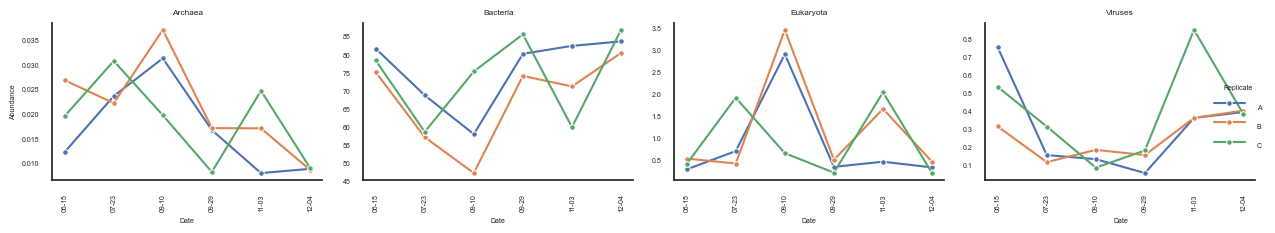

In [1]:
"""
Draw the relative abundance of four domains: 
Archaea, Bacteria, Eukaryota, and Viruses over time and by site.
"""
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ===== Parameters to adjust font sizes =====
title_fontsize = 6
label_fontsize = 5
tick_fontsize = 5
legend_fontsize = 5

# ===== Load data =====
df = pd.read_csv("kaiju_eqR4m_totalNum_genus.tsv", sep="\t")

# Extract domain from the first token before ';'
df["Domain"] = df["taxon_name"].str.split(";").str[0]

# Melt to long format
df_long = df.melt(
    id_vars=["taxon_name", "Domain"],
    var_name="Sample",
    value_name="Abundance"
)

# Extract timepoint and replicate info
df_long["Timepoint"] = df_long["Sample"].str.extract(r"(mG19_\d{2}-\d{1,2})")
df_long["Replicate"] = df_long["Sample"].str.extract(r"-(\d)$")

# Sum abundances for each Domain × Timepoint × Replicate
df_sum = (
    df_long.groupby(["Domain", "Timepoint", "Replicate"], as_index=False)
    .agg({"Abundance": "sum"})
)

# Standardize timepoint format and sort
df_sum["Timepoint"] = df_sum["Timepoint"].str.replace("mG19_", "", regex=False)
df_sum["Date"] = pd.to_datetime(df_sum["Timepoint"], format="%m-%d")

# Map replicates 1/2/3 → A/B/C
rep_map = {"1": "A", "2": "B", "3": "C"}
df_sum["Replicate"] = df_sum["Replicate"].map(rep_map)

# Ensure all replicate × timepoint × domain combinations exist
all_domains = df_sum["Domain"].unique()
all_reps = ["A", "B", "C"]
all_dates = pd.to_datetime(["06-15", "07-23", "09-10", "09-29", "11-03", "12-04"], format="%m-%d")

full_index = pd.MultiIndex.from_product(
    [all_domains, all_reps, all_dates],
    names=["Domain", "Replicate", "Date"]
)

df_sum = (
    df_sum.set_index(["Domain", "Replicate", "Date"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

# Add string timepoint for x-axis labels
df_sum["Timepoint"] = df_sum["Date"].dt.strftime("%m-%d")

# ===== Plotting =====
sns.set(style="white")

domain_order = ["Archaea", "Bacteria", "Eukaryota", "Viruses"]

g = sns.FacetGrid(
    df_sum, col="Domain", hue="Replicate",  
    col_wrap=4, height=2.5, aspect=1.2, sharey=False,
    col_order=domain_order
)

# Marker size is controlled here
g.map(sns.lineplot, "Timepoint", "Abundance", marker="o", markersize=4)

# Add legend and adjust font sizes
legend = g.add_legend(title="Replicate")
for text in legend.legend.texts:
    text.set_fontsize(legend_fontsize)
legend.legend.get_title().set_fontsize(legend_fontsize)

# Axis titles
g.set_titles("{col_name}", size=title_fontsize)
g.set_axis_labels("Date", "Abundance")
for ax in g.axes.flatten():
    ax.set_xlabel(ax.get_xlabel(), fontsize=label_fontsize)
    ax.set_ylabel(ax.get_ylabel(), fontsize=label_fontsize)
    ax.tick_params(axis='x', rotation=90, labelsize=tick_fontsize)
    ax.tick_params(axis='y', labelsize=tick_fontsize)

plt.tight_layout()
plt.savefig("RelativeAbundance_4domains_byTime.svg")
plt.show()


/var/folders/q8/45j4yxgj74xdlr3bmd6mnm38x0hp4l/T/ipykernel_45618/736240732.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tdf.drop(columns=['taxon_name'], inplace=True)
/var/folders/q8/45j4yxgj74xdlr3bmd6mnm38x0hp4l/T/ipykernel_45618/736240732.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  log_tdf = tdf.applymap(lambda x: np.log10(x + 1) if x > 0 else 0)


Minimum value above zero: 0.036
(15, 18)


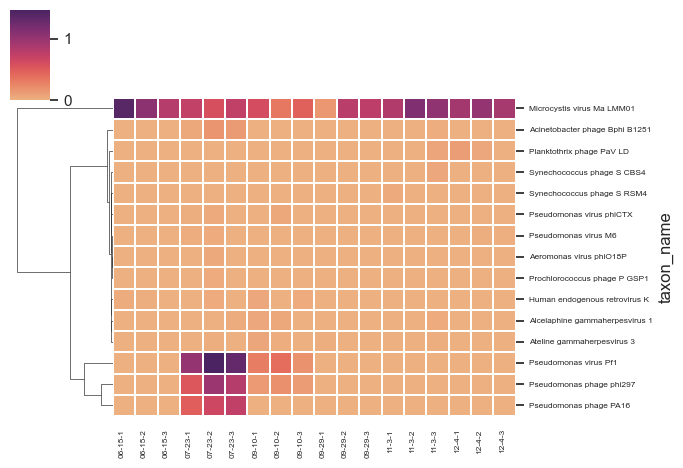

In [59]:
## plot the main taxa abundance in Viruss
import pandas as pd
import re
from collections import defaultdict

#df = pd.read_csv('kaiju_eqR4m_totalNum_genus.tsv', sep='\t')
df = pd.read_csv('kaiju_eqR4m_totalNum_species.tsv', sep='\t')
tdf = df[df['taxon_name'].str.contains('Viruses')]

tdf.columns =tdf.columns.str.replace('mG19_', '', regex=False).astype(str)
#print(tdf.head(3))
def extract_2nd_and_2nd_last(s):
    if isinstance(s, str):
        parts = [p for p in s.split(';') if p]  # filter out empty strings
        if len(parts) >= 4:  # need at least 4 parts to have 2nd and 2nd-last
            return f"{parts[1]}_{parts[-1]}"
    return None


# Apply to the DataFrame column
tdf.index = tdf['taxon_name'].apply(extract_2nd_and_2nd_last)
tdf.drop(columns=['taxon_name'], inplace=True)

#print(tdf.head(3))
mmin = tdf[tdf>0].min().min() * 5
print("Minimum value above zero:", mmin)
tdf =tdf[tdf.gt(mmin).any(axis=1)]
print(tdf.shape)
log_tdf = tdf.applymap(lambda x: np.log10(x + 1) if x > 0 else 0)
log_tdf.index= log_tdf.index.str.replace('Viruses_unclassified_', '', regex=False)
log_tdf.index= log_tdf.index.str.replace('_', ' ')
# plot heatmap for Archaea, Bacteria and Eukaryota
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")
# Use a refined colormap (rocket is similar to Nature's heatmaps)
cmap = sns.color_palette("flare", as_cmap=True)

# Draw the clustered heatmap
g = sns.clustermap(
    log_tdf,
    cmap=cmap,
    figsize=(8, 5),
    metric="euclidean",
    method="average",
    linewidths=0.1,
    yticklabels=True,
    xticklabels=True,
    col_cluster=False
)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=6)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right', fontsize=6)
plt.savefig('mG19_Viruses_species_top20log_heatmap.pdf', bbox_inches='tight')
plt.show()



/var/folders/q8/45j4yxgj74xdlr3bmd6mnm38x0hp4l/T/ipykernel_45618/2629353024.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tdf.drop(columns=['taxon_name'], inplace=True)
/var/folders/q8/45j4yxgj74xdlr3bmd6mnm38x0hp4l/T/ipykernel_45618/2629353024.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  log_tdf = tdf.applymap(lambda x: np.log10(x + 1) if x > 0 else 0)


Minimum value above zero: 0.000695
(20, 18)


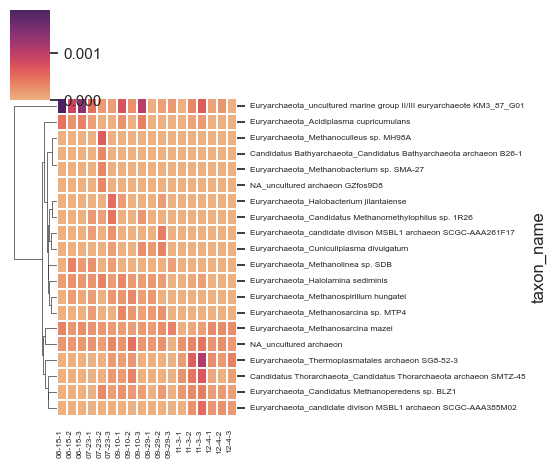

In [ ]:

## plot the main taxa abundance in Archaea 
import pandas as pd
import re
from collections import defaultdict

#df = pd.read_csv('kaiju_eqR4m_totalNum_genus.tsv', sep='\t')
df = pd.read_csv('kaiju_eqR4m_totalNum_species.tsv', sep='\t')
tdf = df[df['taxon_name'].str.contains('Archaea')]

tdf.columns =tdf.columns.str.replace('mG19_', '', regex=False).astype(str)
#print(tdf.head(3))
def extract_2nd_and_2nd_last(s):
    if isinstance(s, str):
        parts = [p for p in s.split(';') if p]  # filter out empty strings
        if len(parts) >= 4:  # need at least 4 parts to have 2nd and 2nd-last
            return f"{parts[1]}_{parts[-1]}"
    return None


# Apply to the DataFrame column
tdf.index = tdf['taxon_name'].apply(extract_2nd_and_2nd_last)
tdf.drop(columns=['taxon_name'], inplace=True)

#print(tdf.head(3))
mmin = tdf[tdf>0].min().min() * 5
print("Minimum value above zero:", mmin)
tdf =tdf[tdf.gt(mmin).any(axis=1)]
print(tdf.shape)
log_tdf = tdf.applymap(lambda x: np.log10(x + 1) if x > 0 else 0)
# plot heatmap for Archaea, Bacteria and Eukaryota
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")
# Use a refined colormap (rocket is similar to Nature's heatmaps)
cmap = sns.color_palette("flare", as_cmap=True)

# Draw the clustered heatmap
g = sns.clustermap(
    log_tdf,
    cmap=cmap,
    figsize=(8, 5),
    metric="euclidean",
    method="average",
    linewidths=0.1,
    yticklabels=True,
    xticklabels=True,
    col_cluster=False
)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=6)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right', fontsize=6)
plt.savefig('mG19_Archaea_species_top20log_heatmap.pdf', bbox_inches='tight')
plt.show()



           0            1             2             3             4  \
0  Eukaryota  Apicomplexa  Aconoidasida  Haemosporida  Plasmodiidae   
1  Eukaryota  Apicomplexa  Aconoidasida           NaN    Babesiidae   

            5   6                                                  7  
0  Plasmodium NaN  Eukaryota;Apicomplexa;Aconoidasida;Haemosporid...  
1     Babesia NaN  Eukaryota;Apicomplexa;Aconoidasida;Haemosporid...  
Maximum value above zero: 1.111954
(20, 18)
1900         Plasmodium
1901            Babesia
1902          Theileria
1903    Cryptosporidium
1904         Cyclospora
Name: taxon_name, dtype: object
1900    NaN
1901    NaN
1902    NaN
1903    NaN
1904    NaN
Name: taxon_name, dtype: object


/var/folders/q8/45j4yxgj74xdlr3bmd6mnm38x0hp4l/T/ipykernel_45618/351782266.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tdf.drop(columns=['taxon_name'], inplace=True)
/var/folders/q8/45j4yxgj74xdlr3bmd6mnm38x0hp4l/T/ipykernel_45618/351782266.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  log_tdf = tdf.applymap(lambda x: np.log10(x + 1) if x > 0 else 0)


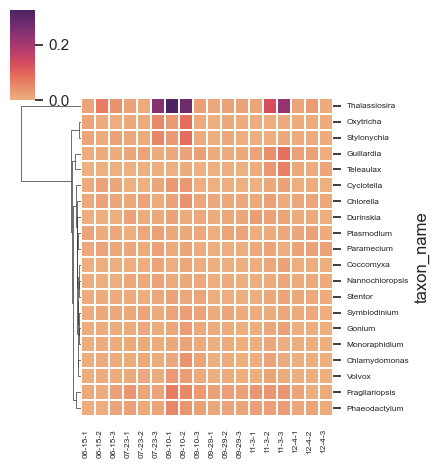

In [53]:
## plot the main taxa abundance in Eukaryota
import pandas as pd
import numpy as np
import re
from collections import defaultdict 

df = pd.read_csv('kaiju_eqR4m_totalNum_genus.tsv', sep='\t')
tdf = df[df['taxon_name'].str.contains('Eukaryota')]
tdf.columns =tdf.columns.str.replace('mG19_', '', regex=False).astype(str)

# this session only applies to Eukaryota for taxon names
sdf = pd.read_csv('kaiju_eqR4m_totalNum_Eukaryotca_genus_phylum_pairs.tsv', sep='\t', header=None)
print(sdf.head(2))
kv = sdf.iloc[:,1].astype(str) + '_' + sdf.iloc[:,-1].astype(str)
#print(kv.head(2))
sdict  = dict(zip(sdf.iloc[:,-1],kv)) 
#genera =tdf['taxon_name'].str.split(';').str[5]
genera = tdf['taxon_name'].str.strip(';').str.split(';').str[-1]
tdf.index = genera
tdf.index = genera.map(sdict).fillna(genera)

tdf.drop(columns=['taxon_name'], inplace=True)

vmax = tdf[tdf>0].max().max()
print("Maximum value above zero:", vmax)
vmin = tdf[tdf>0].min().min() * 196
tdf = tdf[tdf.gt(vmin).any(axis=1)]
tdf = tdf.where(tdf >0.01, tdf * 5)
log_tdf = tdf.applymap(lambda x: np.log10(x + 1) if x > 0 else 0)
print(tdf.shape)
print(genera.head())
print(genera.map(sdict).head())

# plot heatmap for Archaea, Bacteria and Eukaryota
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")
# Use a refined colormap (rocket is similar to Nature's heatmaps)
cmap = sns.color_palette("flare", as_cmap=True)

# Draw the clustered heatmap
g = sns.clustermap(
    log_tdf,
    cmap=cmap,
    figsize=(5, 5),
    metric="euclidean",
    method="average",
    linewidths=0.1,
    yticklabels=True,
    xticklabels=True,
    col_cluster=False,  # Disable column clustering
    cbar_kws={'shrink': 0.95}
)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=6)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right', fontsize=6)
plt.savefig('mG19_eukaryota_genus_top20log_heatmap.pdf', bbox_inches='tight')
plt.show()
#


/var/folders/q8/45j4yxgj74xdlr3bmd6mnm38x0hp4l/T/ipykernel_45618/60338063.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tdf.drop(columns=['taxon_name'], inplace=True)
/var/folders/q8/45j4yxgj74xdlr3bmd6mnm38x0hp4l/T/ipykernel_45618/60338063.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  log_tdf = tdf.applymap(lambda x: np.log10(x + 1) if x > 0 else 0)


Minimum value above zero: 0.1251
(50, 18)


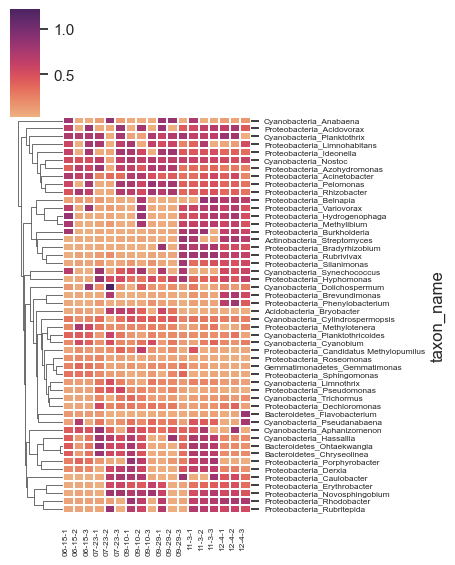

In [70]:
## plot the main taxa abundance in Bacteria 
import pandas as pd
import re
from collections import defaultdict

df = pd.read_csv('kaiju_eqR4m_totalNum_genus.tsv', sep='\t')
#df = pd.read_csv('kaiju_eqR4m_totalNum_species.tsv', sep='\t')
tdf = df[df['taxon_name'].str.contains('Bacteria')]

tdf.columns =tdf.columns.str.replace('mG19_', '', regex=False).astype(str)
#print(tdf.head(3))
def extract_2nd_and_2nd_last(s):
    if isinstance(s, str):
        parts = [p for p in s.split(';') if p]  # filter out empty strings
        if len(parts) >= 4:  # need at least 4 parts to have 2nd and 2nd-last
            return f"{parts[1]}_{parts[-1]}"
    return None


# Apply to the DataFrame column
tdf.index = tdf['taxon_name'].apply(extract_2nd_and_2nd_last)
tdf.drop(columns=['taxon_name'], inplace=True)

#print(tdf.head(3))
mmin = tdf[tdf>0].min().min() * 900
print("Minimum value above zero:", mmin)
tdf =tdf[tdf.gt(mmin).any(axis=1)]
tdf = tdf.where(tdf >0.08, tdf *75)
log_tdf = tdf.applymap(lambda x: np.log10(x + 1) if x > 0 else 0)
log_tdf=log_tdf[~log_tdf.index.str.contains('Microcystis')]
print(log_tdf.shape)

# plot heatmap for Archaea, Bacteria and Eukaryota
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")
# Use a refined colormap (rocket is similar to Nature's heatmaps)
cmap = sns.color_palette("flare", as_cmap=True)

# Draw the clustered heatmap
g = sns.clustermap(
    log_tdf,
    cmap=cmap,
    figsize=(6, 6),
    metric="euclidean",
    method="average",
    linewidths=0.1,
    yticklabels=True,
    xticklabels=True,
    col_cluster=False,  # Disable column clustering
    cbar_kws={'shrink': 0.95}  # Adjust colorbar size
)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=6)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right', fontsize=6)
plt.savefig('mG19_Bacteria_genus_top50log_heatmap.pdf', bbox_inches='tight')
plt.show()



Index(['mG19_06-15-1', 'mG19_06-15-2', 'mG19_06-15-3', 'mG19_07-23-1',
       'mG19_07-23-2', 'mG19_07-23-3', 'mG19_09-10-1', 'mG19_09-10-2',
       'mG19_09-10-3', 'mG19_09-29-1', 'mG19_09-29-2', 'mG19_09-29-3',
       'mG19_11-3-1', 'mG19_11-3-2', 'mG19_11-3-3', 'mG19_12-4-1',
       'mG19_12-4-2', 'mG19_12-4-3'],
      dtype='object')
['Microcystis aeruginosa', 'Microcystis wesenbergii', 'Microcystis panniformis', 'Chlamydomonas leiostraca', 'Chlamydomonas reinhardtii', 'Chlamydomonas peterfii', 'Chlorella sorokiniana', 'Chlorella vulgaris', 'Thalassiosira pseudonana', 'Guillardia theta', 'Durinskia baltica', 'Emiliania huxleyi']


/var/folders/q8/45j4yxgj74xdlr3bmd6mnm38x0hp4l/T/ipykernel_15393/7587279.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(timepoints, rotation=90,  fontsize=9)
/var/folders/q8/45j4yxgj74xdlr3bmd6mnm38x0hp4l/T/ipykernel_15393/7587279.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(timepoints, rotation=90,  fontsize=9)
/var/folders/q8/45j4yxgj74xdlr3bmd6mnm38x0hp4l/T/ipykernel_15393/7587279.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(timepoints, rotation=90,  fontsize=9)
/var/folders/q8/45j4yxgj74xdlr3bmd6mnm38x0hp4l/T/ipykernel_15393/7587279.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fixed

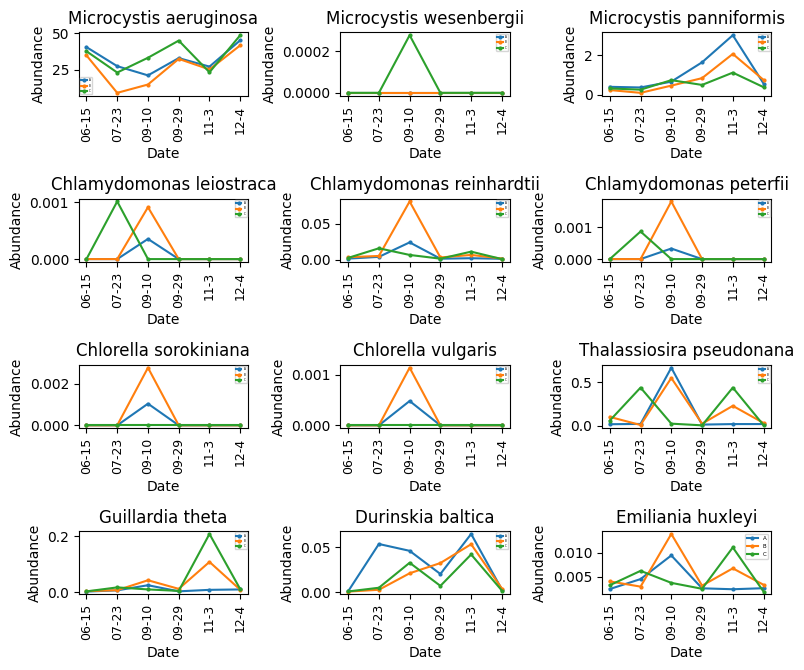

In [ ]:
""" selects and plots taxa closely related to temperature changes."""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1. Load your dataframe (replace with your actual file)
df =pd.read_csv('kaiju_eqR4m_totalNum_species.tsv', sep='\t', index_col=0)
#df = df.iloc[:, :12]  # first 4 timepoints × 3 replicates
print(df.columns)
# Timepoint labels (adjust based on your actual timepoints)
timepoints = df.columns.str.replace('mG19_', '', regex=False).astype(str).str.rsplit('-', n=1).str[0].unique()
replicates = 3
sites = ['A', 'B', 'C']
#####-------------------the beginning of algal phyla plotting -------------------
# #phyla = df[df.index.str.startswith('Bacteria;Cyanobacteria')].index.str.split(';').str[1].unique()
# phyla = ['Bacteria;Cyanobacteria', 'Eukaryota;Bacillariophyta', 'Eukaryota;Chlorophyta', 'Eukaryota;Cryptophyta', 'Eukaryota;Dinoflagellata', 'Eukaryota;Rhodophyta', 'Eukaryota;Haptophyta', 'Eukaryota;Ochrophyta']

# # Create figure with 4 rows × 2 columns = 8 subplots
# fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(5, 6))
# axes = axes.flatten()
# # Loop over each phylum and corresponding axis
# for i, phylum in enumerate(phyla):
#     ax = axes[i]
    
#     # Filter and sum data
#     tdf = df[df.index.str.contains(phylum)]
#     tdf = tdf[tdf.sum(axis=1) > 0]
    
#     if tdf.empty:
#         ax.set_title(f"{phylum} (no data)")
#         ax.axis('off')  # Hide empty subplot
#         continue

#     sum_vec = tdf.sum(axis=0)
#     rep_lines = [sum_vec[j::replicates].values for j in range(replicates)]
    
#     # Plot three replicates
#     for r in range(replicates):
#         y = rep_lines[r]
#         if not pd.isna(y).all():
#             ax.plot(timepoints, y, label=sites[r], marker='o', markersize=2)

#     ax.set_title(phylum.split(';')[-1])  # Use short name
#     ax.set_xlabel("Date")
#     ax.set_ylabel("Abundance")
#     ax.legend(fontsize=2)

# # Hide any unused subplots (if fewer than 8)
# for j in range(len(phyla), len(axes)):
#     axes[j].axis('off')

# plt.tight_layout()
# plt.legend(fontsize=4)
# #plt.savefig('main_phyla_abundance_temperature_byDate.pdf', bbox_inches='tight')
# plt.show()
#####-------------------the END of algal phyla plotting -------------------
#####-------------------the begining of plots select algal species -------------------
genus_ma = ['Microcystis aeruginosa', 'Microcystis wesenbergii', 'Microcystis panniformis']
genus_ch = ['Chlamydomonas leiostraca','Chlamydomonas reinhardtii' ,'Chlamydomonas peterfii']
geus_chlorella = ['Chlorella sorokiniana', 'Chlorella vulgaris']
genus_diatom = ['Thalassiosira pseudonana']
genus_cryptophyte = ['Guillardia theta']
genus_dinoflagellate = [ 'Durinskia baltica']
genus_haplophyte = ['Emiliania huxleyi']
genera = genus_ma + genus_ch + geus_chlorella + genus_diatom + genus_cryptophyte + genus_dinoflagellate + genus_haplophyte
print(genera)

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(8, 6.8))
axes = axes.flatten()

# Loop over each phylum and corresponding axis
for i, genus in enumerate(genera):
    ax = axes[i]
    
    # Filter and sum data
    tdf = df[df.index.str.contains(genus)]
    tdf = tdf[tdf.sum(axis=1) > 0]
    sum_vec =[]
    if tdf.empty:
        ax.set_title(f"{genus} (no data)")
        ax.axis('off')  # Hide empty subplot
        continue

    sum_vec = tdf.sum(axis=0)
    rep_lines = [sum_vec[j::replicates].values for j in range(replicates)]
    
    # Plot three replicates
    for r in range(replicates):
        y = rep_lines[r]
        if not pd.isna(y).all():
            ax.plot(timepoints, y, label=sites[r], marker='o', markersize=2)

    ax.set_title(genus.split(';')[-1])  # Use short name
    ax.set_xlabel("Date")
    ax.set_ylabel("Abundance")
    ax.set_xticklabels(timepoints, rotation=90,  fontsize=9)
    ax.legend(fontsize=2)

# Hide any unused subplots (if fewer than 8)
for j in range(len(genera), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.legend(fontsize=4)
#plt.savefig('7mainGenus_species_abundance_temperature_by_6-Date.pdf', bbox_inches='tight')
plt.show()


Index(['mG19_06-15-1', 'mG19_06-15-2', 'mG19_06-15-3', 'mG19_07-23-1',
       'mG19_07-23-2', 'mG19_07-23-3', 'mG19_09-10-1', 'mG19_09-10-2',
       'mG19_09-10-3', 'mG19_09-29-1', 'mG19_09-29-2', 'mG19_09-29-3',
       'mG19_11-3-1', 'mG19_11-3-2', 'mG19_11-3-3', 'mG19_12-4-1',
       'mG19_12-4-2', 'mG19_12-4-3'],
      dtype='object')
Index(['Microcystis flos_aquae', 'Microcystis panniformis',
       'Microcystis wesenbergii', 'Dolichospermum compactum'],
      dtype='object', name='clade_name')


/var/folders/q8/45j4yxgj74xdlr3bmd6mnm38x0hp4l/T/ipykernel_15393/245531488.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(timepoints, rotation=90, fontsize=10)
/var/folders/q8/45j4yxgj74xdlr3bmd6mnm38x0hp4l/T/ipykernel_15393/245531488.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(timepoints, rotation=90, fontsize=10)
/var/folders/q8/45j4yxgj74xdlr3bmd6mnm38x0hp4l/T/ipykernel_15393/245531488.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(timepoints, rotation=90, fontsize=10)
/var/folders/q8/45j4yxgj74xdlr3bmd6mnm38x0hp4l/T/ipykernel_15393/245531488.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using

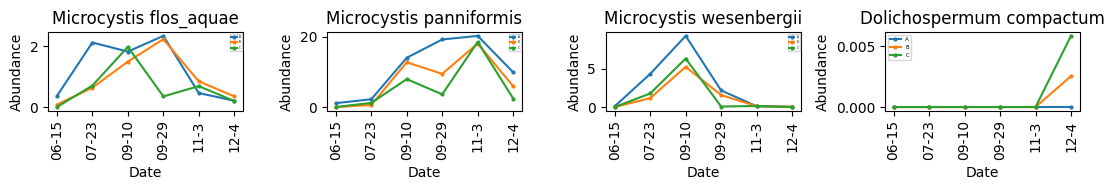

In [16]:
""" selects and plots taxa closely related to temperature changes."""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1. Load your dataframe (replace with your actual file)
df =pd.read_csv('Microcystis_3otherSPecies_abundance_byMPA3.tsv', sep='\t', index_col=0)
#df = df.iloc[:, :12]  # first 4 timepoints × 3 replicates
df = df[sorted(df.columns)]
print(df.columns)
print(df.index)
# Timepoint labels (adjust based on your actual timepoints)
timepoints = df.columns.str.replace('mG19_', '', regex=False).astype(str).str.rsplit('-', n=1).str[0].unique()
replicates = 3
sites = ['A', 'B', 'C']

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(11, 2))
axes = axes.flatten()

# Loop over each phylum and corresponding axis
for i in range(df.shape[0]):
    genus = df.iloc[i]
    ax = axes[i]
    sum_vec =[]
    sum_vec = genus
    rep_lines = [sum_vec[j::replicates].values for j in range(replicates)]
    
    # Plot three replicates
    for r in range(replicates):
        y = rep_lines[r]
        if not pd.isna(y).all():
            ax.plot(timepoints, y, label=sites[r], marker='o', markersize=2)

    ax.set_title(df.index[i])  # Use short name
    ax.set_xlabel("Date")
    ax.set_ylabel("Abundance")
    ax.set_xticklabels(timepoints, rotation=90, fontsize=10)
    ax.legend(fontsize=2)

# Hide any unused subplots (if fewer than 8)
for j in range(len(genera), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.legend(fontsize=4)
plt.savefig('3microcystis_1Dolicho_MPA3abundance_by_6-date.pdf', bbox_inches='tight')
plt.show()




Empty DataFrame
Columns: []
Index: [mG19_06.15.1,25.52,8,10.85,7.34,5.87,1.2535,0.1089,0.3434,0.0263,0.6996,0.670196,25.456808,0.676497696,3.468229973,1.791738136, mG19_06.15.2,26.573,6.9,4.45,0.76,5.19,1.5372,0.1644,0.6693,0.0653,0.2239,0.1905985,14.658668,0.170786517,19.28772105,6.865564984, mG19_06.15.3,27.718,8,6.19,3.09,12.86,0.6511,0.0523,0.0548,0.0017,0.9319,0.504858,12.06509,0.499192246,3.904559871,0.698680116, mG19_07.23.1,32.481,8,7.93,7.88,13.46,1.107,0.1444,0.217,0.029,0.3969,0.363959,2.5576422,0.99369483,0.324573883,2.789115646, mG19_07.23.2,33.133,8.1,7.92,4.59,14.7,0.9696,0.0711,0.2294,0.0303,0.1518,0.1262944,1.9845824,0.579545455,0.432370893,6.387351779, mG19_07.23.3,30.747,8,9.6,2.4,10.89,0.7874,0.0666,0.1994,0.1291,0.1271,0.0885367,2.2292474,0.25,0.928853083,6.195121951, mG19_09.10.1,29.327,7.8,8.2,2.21,11.47,1.5795,0.0543,0.8916,0.1132,0.1704,0.1446669,4.1023326,0.269512195,1.856259095,9.269366197, mG19_09.10.2,31.238,7.2,8.56,1.11,10.12,1.5885,0.2868,0.7421,0.0722,0

/var/folders/q8/45j4yxgj74xdlr3bmd6mnm38x0hp4l/T/ipykernel_66324/1840946349.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(timepoints, rotation=90,  fontsize=10)
/var/folders/q8/45j4yxgj74xdlr3bmd6mnm38x0hp4l/T/ipykernel_66324/1840946349.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(timepoints, rotation=90,  fontsize=10)
/var/folders/q8/45j4yxgj74xdlr3bmd6mnm38x0hp4l/T/ipykernel_66324/1840946349.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(timepoints, rotation=90,  fontsize=10)
/var/folders/q8/45j4yxgj74xdlr3bmd6mnm38x0hp4l/T/ipykernel_66324/1840946349.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() o

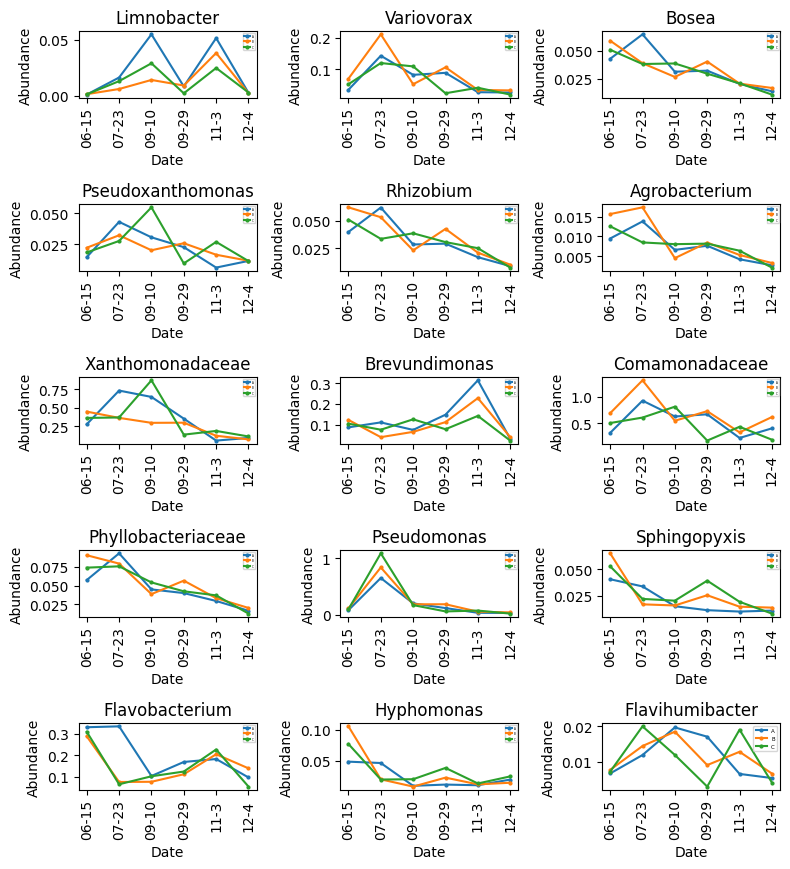

In [ ]:
""" plot epibiont abundance of Microcystis species over time and by site."""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tdf = pd.read_csv('water_chemistry.sv', sep='\t', index_col=0)
print(tdf)

# 1. Load your dataframe (replace with your actual file)
df =pd.read_csv('kaiju_eqR4m_totalNum_species.tsv', sep='\t', index_col=0)
#df = df.iloc[:, :12]  # first 4 timepoints × 3 replicates
print(df.columns)
# Timepoint labels (adjust based on your actual timepoints)
timepoints = df.columns.str.replace('mG19_', '', regex=False).astype(str).str.rsplit('-', n=1).str[0].unique()
replicates = 3
sites = ['A', 'B', 'C']
genera = ['Limnobacter', 'Variovorax', 'Bosea', 'Pseudoxanthomonas', 'Rhizobium', 'Agrobacterium', 'Xanthomonadaceae', 'Brevundimonas', 'Comamonadaceae', 'Phyllobacteriaceae', 'Pseudomonas', 'Sphingopyxis', 'Flavobacterium', 'Hyphomonas', 'Flavihumibacter']
#print(genera)
#print(len(genera))

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(8, 8.8))
axes = axes.flatten()

# Loop over each phylum and corresponding axis
for i, genus in enumerate(genera):
    ax = axes[i]
    
    # Filter and sum data
    tdf = df[df.index.str.contains(genus)]
    tdf = tdf[tdf.sum(axis=1) > 0]
    sum_vec =[]
    if tdf.empty:
        ax.set_title(f"{genus} (no data)")
        ax.axis('off')  # Hide empty subplot
        continue

    sum_vec = tdf.sum(axis=0)
    rep_lines = [sum_vec[j::replicates].values for j in range(replicates)]
    
    # Plot three replicates
    for r in range(replicates):
        y = rep_lines[r]
        if not pd.isna(y).all():
            ax.plot(timepoints, y, label=sites[r], marker='o', markersize=2)

    ax.set_title(genus.split(';')[-1])  # Use short name
    #ax.set_title(tdf.index)
    ax.set_xlabel("Date")
    ax.set_xticklabels(timepoints, rotation=90,  fontsize=10)
    ax.set_ylabel("Abundance")

    ax.legend(fontsize=2)

# Hide any unused subplots (if fewer than 8)
for j in range(len(genera), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.legend(fontsize=4)
#plt.savefig('15mainGenus_epibiont_abundance_by_6-date.pdf', bbox_inches='tight')
plt.show()


<>:45: SyntaxWarning: invalid escape sequence '\d'
<>:45: SyntaxWarning: invalid escape sequence '\d'
/var/folders/q8/45j4yxgj74xdlr3bmd6mnm38x0hp4l/T/ipykernel_95096/337447290.py:45: SyntaxWarning: invalid escape sequence '\d'
  taxon_name = taxon_name.replace('\d$', '')


Index(['mG19_06-15-1', 'mG19_06-15-2', 'mG19_06-15-3', 'mG19_07-23-1',
       'mG19_07-23-2', 'mG19_07-23-3', 'mG19_09-10-1', 'mG19_09-10-2',
       'mG19_09-10-3', 'mG19_09-29-1', 'mG19_09-29-2', 'mG19_09-29-3',
       'mG19_11-3-1', 'mG19_11-3-2', 'mG19_11-3-3', 'mG19_12-4-1',
       'mG19_12-4-2', 'mG19_12-4-3'],
      dtype='object')
Index(['Bacteria;Cyanobacteria;NA;Chroococcales;Microcystaceae;Microcystis;Microcystis aeruginosa;'], dtype='object', name='taxon_name')
Index(['Bacteria;Cyanobacteria;NA;Chroococcales;Microcystaceae;Microcystis;Microcystis flos aquae;'], dtype='object', name='taxon_name')
Index(['Bacteria;Cyanobacteria;NA;Chroococcales;Microcystaceae;Microcystis;Microcystis panniformis2;', 'Bacteria;Cyanobacteria;NA;Chroococcales;Microcystaceae;Microcystis;Microcystis panniformis;'], dtype='object', name='taxon_name')
Index(['Bacteria;Cyanobacteria;NA;Chroococcales;Microcystaceae;Microcystis;Microcystis wesenbergii2;', 'Bacteria;Cyanobacteria;NA;Chroococcales;Microcys

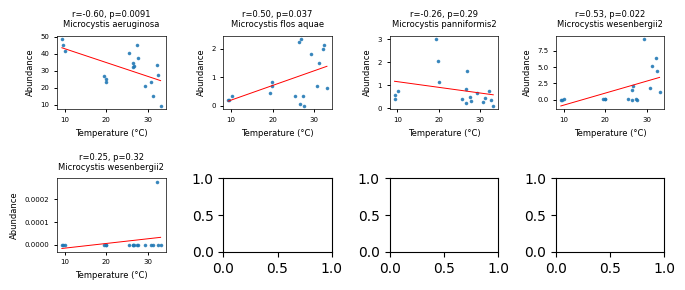

In [2]:
""" plot 
Corr b/w 4 Microcystis species and temperature before 11/3/2019
"""
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
# ## corr at 12 highest temperature timepoints
# #load water chemistry data
# tdf = pd.read_csv('water_chemistry.csv', index_col=0)
# tdf.index = tdf.index.str.replace('.','-', regex=False)
# cdf = pd.DataFrame({'temp': tdf.iloc[0:12, 0].values}, index=tdf.index[0:12])
# tval = cdf['temp'].values
# # 1. Load taxon abundance
# df =pd.read_csv('kaiju_eqR4m_totalNum_species.tsv', sep='\t', index_col=0)
# df = df.iloc[:, :12]  # first 4 timepoints × 3 replicates
# print(df.columns)

## Corr at all tmeporature timepoints
#load water chemistry data
tdf = pd.read_csv('water_chemistry.csv', index_col=0)
tdf.index = tdf.index.str.replace('.','-', regex=False)
cdf = pd.DataFrame({'temp': tdf.iloc[0:18, 0].values}, index=tdf.index[0:18])
tval = cdf['temp'].values
# 1. Load taxon abundance
df =pd.read_csv('kaiju_eqR4m_totalNum_species.tsv', sep='\t', index_col=0)
#df = df.iloc[:, :12]  # first 4 timepoints × 3 replicates
print(df.columns)

genera = ['Microcystis aeruginosa', 'Microcystis flos aquae', 'Microcystis panniformis', 'Microcystis wesenbergii']

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(7, 3))
axes = axes.flatten()
plot_idx = 0
for genus in genera:
    # Filter DataFrame for rows containing the genus
    gdf = df[df.index.str.contains(genus)]
    print(gdf.index)
    gdf = gdf[gdf.sum(axis=1) > 0]
    for species in gdf.index:
        if plot_idx >= len(axes):
            break
        taxonAB = gdf.loc[species]
        taxon_name = gdf.index.astype(str).str.strip(';').str.split(';').str[-1].values[0]
        taxon_name = taxon_name.replace('\d$', '')
        corr_coef, p_value = pearsonr(tval, taxonAB)
        # Only plot if correlation is strong and significant
        if abs(corr_coef) > 0.2 and p_value < 0.5:
            ax = axes[plot_idx]
            parts = species.split(';')[-2]
            sns.regplot(x=tval, y=taxonAB, ci=None, line_kws={"color": "red", "linewidth":0.7}, ax=ax, scatter_kws={"s": 2.5})
            ax.grid(False)
            ax.set_title(f"r={corr_coef:.2f}, p={p_value:.2g}\n{taxon_name}", fontsize=6)
            ax.set_xlabel("Temperature (°C)", fontsize=6)
            ax.set_ylabel("Abundance", fontsize=6)
            ax.tick_params(axis='both', labelsize=5, width=0.7, length=2, bottom=True, left=True, labelbottom=True, labelleft=True)
            for spine in ax.spines.values():
                spine.set_linewidth(0.5)
            plot_idx += 1
plt.tight_layout()
plt.savefig('Microcystis_4spcies_tmperature-18points_corr.pdf',bbox_inches='tight', dpi=300)
plt.show()

(1, 12)


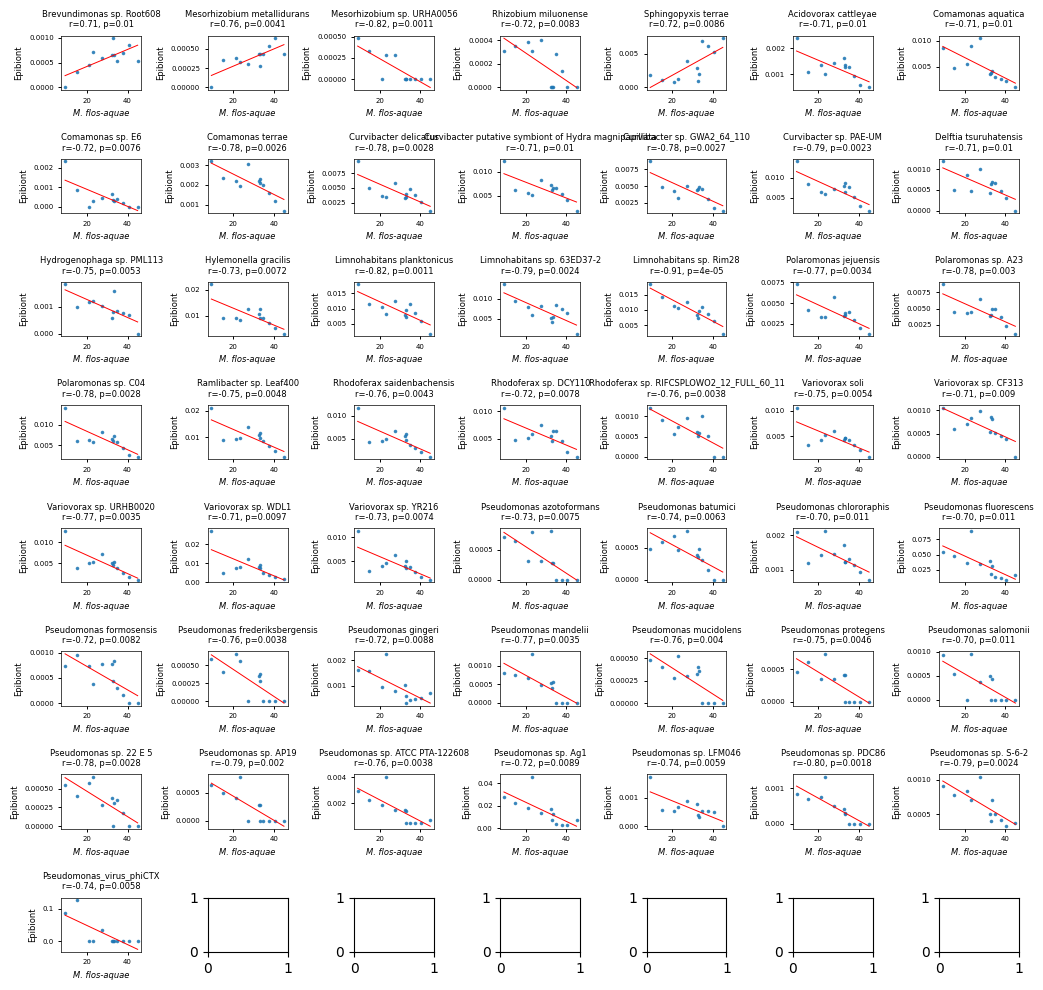

In [ ]:
""" plot 
correlation b/w microcystis with epibiotic bacteria before 11/3/2019
"""
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. Load taxon abundance
df =pd.read_csv('kaiju_eqR4m_totalNum_species.tsv', sep='\t', index_col=0)
# only 4 timepoints × 3 replicates
df = df.iloc[:, :12]  # first 4 timepoints × 3 replicates
## plots epibiotic bacteria correlation with temperature
# genera = ['Limnobacter', 'Variovorax', 'Bosea', 'Pseudoxanthomonas', 'Rhizobium', 'Agrobacterium', 'Xanthomonadaceae', 
#           'Brevundimonas', 'Comamonadaceae', 'Phyllobacteriaceae', 'Pseudomonas', 'Sphingopyxis', 'Flavobacterium', 'Hyphomonas',
#           'Flavihumibacter']
m3= ['Microcystis aeruginosa', 'Microcystis flos aquae', 'Microcystis wesenbergii2']
m3_xtitle=['M. aeruginosa', 'M. flos-aquae', 'M. wesenbergii']
mdict = {'Microcystis aeruginosa': ['Limnobacter', 'Variovorax', 'Bosea', 'Pseudoxanthomonas', 'Rhizobium','Agrobacterium', 'Xanthomonadaceae', 'Brevundimonas'],
         'Microcystis wesenbergii2':['Flavobacterium', 'Limnobacter', 'Hyphomonas', 'Pseudoxanthomonas', 'Bosea', 'Rhizobium', 'Agrobacterium', 'Pseudomonas', 'Flavihumibacter'],
         'Microcystis flos aquae': ['Limnobacter', 'Comamonadaceae', 'Phyllobacteriaceae', 'Pseudoxanthomonas', 'Rhizobium', 'Agrobacterium', 'Pseudomonas', 'Sphingopyxis', 'Brevundimonas']}
df_mar = df[df.index.str.contains(m3[0])]
print(df_mar.shape)

ii=0
genera = mdict[m3[ii]]
fig, axes = plt.subplots(nrows=1, ncols=7, figsize=(10.5, 1.25)) # M. aeruginosa
#ii=1
#genera = mdict[m3[ii]]
#fig, axes = plt.subplots(nrows=8, ncols=7, figsize=(10.5, 10)) # M.flos aquae
#ii=2
#genera = mdict[m3[ii]]
#fig, axes = plt.subplots(nrows=4, ncols=7, figsize=(10.5, 6)) # M. wesenbergii

axes = axes.flatten()
highcorr_dict = {}
plot_idx = 0
for i in range(df.shape[0]):
    indx_str = df.index[i]
    taxonAB = df.iloc[i]
    if not any(species in df.index[i] for species in genera):
        continue
    if np.all(taxonAB.values == taxonAB.values[0]):
        continue

    corr_coef, p_value = pearsonr(df_mar.values.flatten(), taxonAB.values)
    if abs(corr_coef) > 0.7 and p_value < 0.05:
        parts = df.index[i].split(';')
        taxon_name = f"{parts[-2]}"
        ax = axes[plot_idx]
        microcystis_abundance = df_mar.iloc[0].values  # or use .loc[...] for the exact species
        sns.regplot(x=microcystis_abundance, y=taxonAB.values, ci=None, line_kws={"color": "red", "linewidth":0.7}, scatter_kws={"s": 2.5}, ax=ax)
        ax.grid(False)
        ax.set_title(f"{taxon_name}\nr={corr_coef:.2f}, p={p_value:.2g}", fontsize=6)
        ax.set_xlabel(m3_xtitle[ii], fontsize=6)
        ax.tick_params(axis='x', labelsize=5)
        ax.set_ylabel("Epibiont", fontsize=6)
        ax.tick_params(axis='y', labelsize=5)
        ax.tick_params(axis='both', labelsize=5, width=0.7, length=2, bottom=True, left=True, labelbottom=True, labelleft=True)
        ax.xaxis.label.set_fontstyle('italic')
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)
        plot_idx += 1

plt.tight_layout()
plt.savefig('M_aeruginosa_epibiont_corr_w-4temperature_plots.pdf', bbox_inches='tight', dpi=300)
plt.show()



Index(['mG19_06-15-1', 'mG19_06-15-2', 'mG19_06-15-3', 'mG19_07-23-1',
       'mG19_07-23-2', 'mG19_07-23-3', 'mG19_09-10-1', 'mG19_09-10-2',
       'mG19_09-10-3', 'mG19_09-29-1', 'mG19_09-29-2', 'mG19_09-29-3'],
      dtype='object')


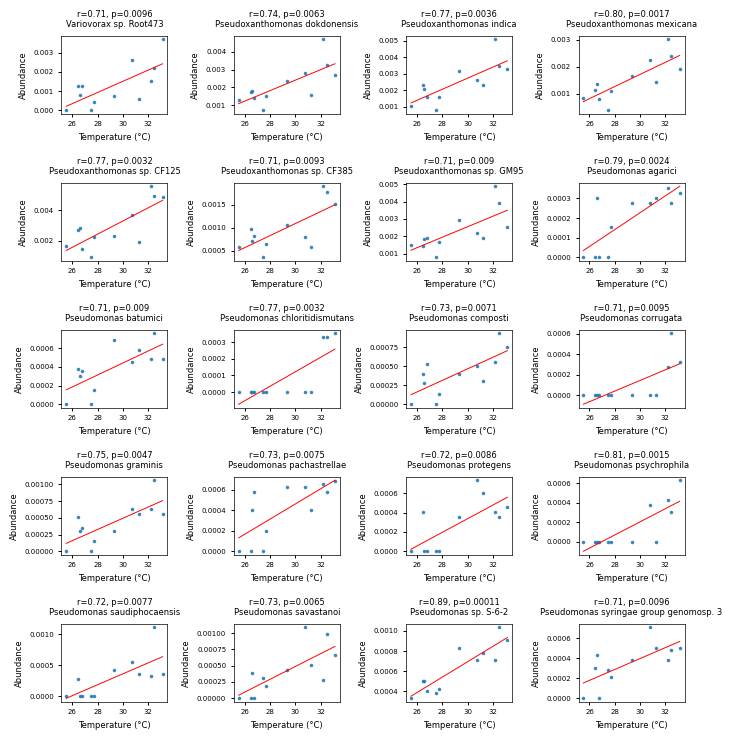

20


In [12]:
""" plot 
Corr b/w epibiotic bacteria and temperature before 11/3/2019
"""
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

#load water chemistry data
tdf = pd.read_csv('water_chemistry.csv', index_col=0)
tdf.index = tdf.index.str.replace('.','-', regex=False)
cdf = pd.DataFrame({'temp': tdf.iloc[0:12, 0].values}, index=tdf.index[0:12])
tval = cdf['temp'].values

# 1. Load taxon abundance
df =pd.read_csv('kaiju_eqR4m_totalNum_species.tsv', sep='\t', index_col=0)
df = df.iloc[:, :12]  # first 4 timepoints × 3 replicates
print(df.columns)
genera = ['Limnobacter', 'Variovorax', 'Bosea', 'Pseudoxanthomonas', 'Rhizobium', 'Agrobacterium',  
          'Brevundimonas',  'Pseudomonas', 'Sphingopyxis', 'Flavobacterium', 'Hyphomonas', 'Flavihumibacter']

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(7, 7.5))
axes = axes.flatten()
plot_idx = 0
for genus in genera:
    # Filter DataFrame for rows containing the genus
    gdf = df[df.index.str.contains(genus)]
    gdf = gdf[gdf.sum(axis=1) > 0]
    for species in gdf.index:
        if plot_idx >= len(axes):
            break
        taxonAB = gdf.loc[species]
        corr_coef, p_value = pearsonr(tval, taxonAB)
        # Only plot if correlation is strong and significant
        if abs(corr_coef) > 0.7 and p_value < 0.01:
            ax = axes[plot_idx]
            taxon_name = species.split(';')[-2]
            #taxon_name = species.astype(str).str.strip(';').str.split(';').str[-1].values[0]
            #taxon_name = taxon_name.replace('\d$', '')
            sns.regplot(x=tval, y=taxonAB, ci=None, line_kws={"color": "red", "linewidth":0.7}, ax=ax, scatter_kws={"s": 2.5})
            ax.grid(False)
            ax.set_title(f"r={corr_coef:.2f}, p={p_value:.2g}\n{taxon_name}", fontsize=6)
            ax.set_xlabel("Temperature (°C)", fontsize=6)
            ax.set_ylabel("Abundance", fontsize=6)
            ax.tick_params(axis='y', labelsize=5)
            ax.tick_params(axis='x', labelsize=5)
            ax.tick_params(axis='both', labelsize=5, width=0.7, length=2, bottom=True, left=True, labelbottom=True, labelleft=True)
            for spine in ax.spines.values():
                spine.set_linewidth(0.5)
            plot_idx += 1
plt.tight_layout()
plt.savefig('Microcystis_epibiotic_bacteria_corr_w-tmperature_26plots_small.pdf', bbox_inches='tight')
plt.show()
print(plot_idx)

                temp
SampleID            
mG19_06-15-1  25.520
mG19_06-15-2  26.573
mG19_06-15-3  27.718
mG19_07-23-1  32.481
mG19_07-23-2  33.133
mG19_07-23-3  30.747
mG19_09-10-1  29.327
mG19_09-10-2  31.238
mG19_09-10-3  32.182
mG19_09-29-1  26.763
mG19_09-29-2  26.465
mG19_09-29-3  27.457
[25.52  26.573 27.718 32.481 33.133 30.747 29.327 31.238 32.182 26.763
 26.465 27.457]
Index(['mG19_06-15-1', 'mG19_06-15-2', 'mG19_06-15-3', 'mG19_07-23-1',
       'mG19_07-23-2', 'mG19_07-23-3', 'mG19_09-10-1', 'mG19_09-10-2',
       'mG19_09-10-3', 'mG19_09-29-1', 'mG19_09-29-2', 'mG19_09-29-3'],
      dtype='object')


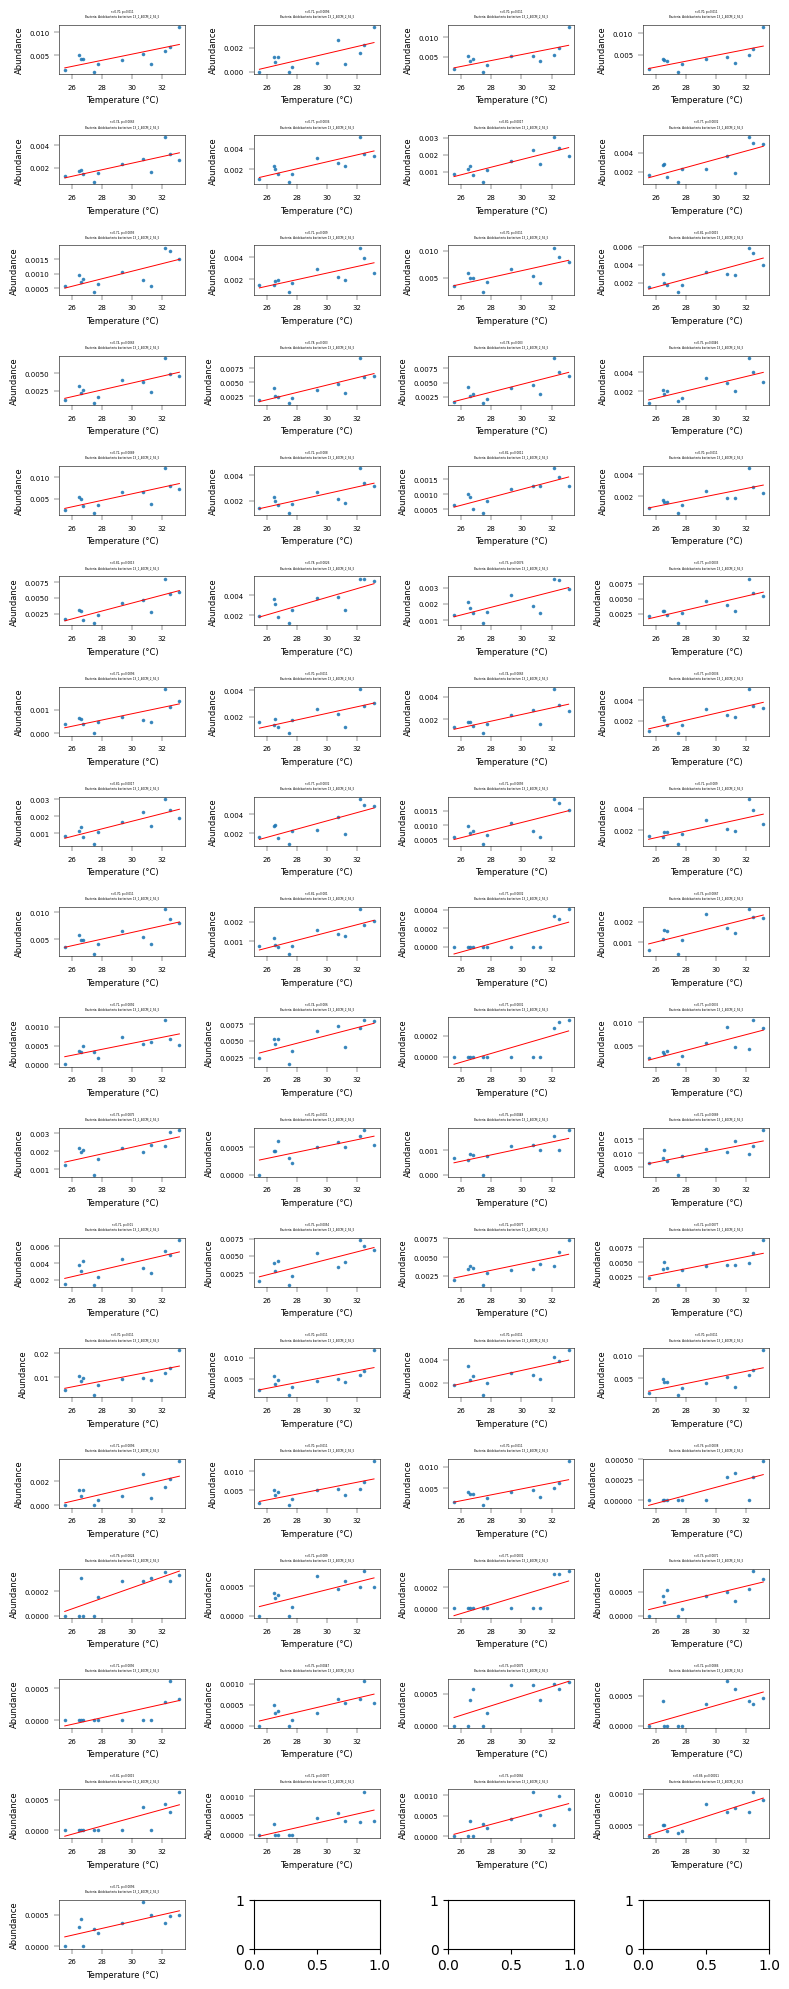

69


In [22]:
""" plot 
correlation b/w microcystis with epibiotic bacteria before 11/3/2019
"""
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

#load water chemistry data
tdf = pd.read_csv('water_chemistry.csv', index_col=0)
tdf.index = tdf.index.str.replace('.','-', regex=False)
cdf = pd.DataFrame({'temp': tdf.iloc[0:12, 0].values}, index=tdf.index[0:12])
tval = cdf['temp'].values
print(cdf)
print(tval)
# 1. Load taxon abundance
df =pd.read_csv('kaiju_eqR4m_totalNum_species.tsv', sep='\t', index_col=0)
df = df.iloc[:, :12]  # first 4 timepoints × 3 replicates
print(df.columns)
genera = ['Limnobacter', 'Variovorax', 'Bosea', 'Pseudoxanthomonas', 'Rhizobium', 'Agrobacterium', 'Xanthomonadaceae', 
          'Brevundimonas', 'Comamonadaceae', 'Phyllobacteriaceae', 'Pseudomonas', 'Sphingopyxis', 'Flavobacterium', 'Hyphomonas',
          'Flavihumibacter']

fig, axes = plt.subplots(nrows=18, ncols=4, figsize=(8, 20))
axes = axes.flatten()
plot_idx = 0
for genus in genera:
    # Filter DataFrame for rows containing the genus
    gdf = df[df.index.str.contains(genus)]
    gdf = gdf[gdf.sum(axis=1) > 0]
    for species in gdf.index:
        if plot_idx >= len(axes):
            break
        taxonAB = gdf.loc[species]
        corr_coef, p_value = pearsonr(tval, taxonAB)
        # Only plot if correlation is strong and significant
        if abs(corr_coef) > 0.7 and p_value < 0.05:
            ax = axes[plot_idx]
            parts = species.split(';')[-2]
            sns.regplot(x=tval, y=taxonAB, ci=None, line_kws={"color": "red", "linewidth":0.7}, ax=ax, scatter_kws={"s": 2.5})
            ax.set_title(f"r={corr_coef:.2f}, p={p_value:.2g}\n{taxon_name}", fontsize=2)
            ax.set_xlabel("Temperature (°C)", fontsize=6)
            ax.set_ylabel("Abundance", fontsize=6)
            ax.tick_params(axis='y', labelsize=5)
            ax.tick_params(axis='x', labelsize=5)
            ax.tick_params(axis='both', width=0.3)  # thinner ticks
            for spine in ax.spines.values():
                spine.set_linewidth(0.4)
            plot_idx += 1
plt.tight_layout()
#plt.savefig('epibiotic_bacteria_corr_w-tmperature_69plots_small.pdf', bbox_inches='tight')
plt.show()
print(plot_idx)

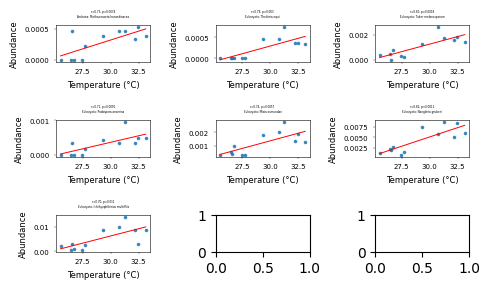

0 0 0 0


In [30]:
""" plot 
corrleaton b/w temperature and species before 11/3/2019
correlation b/w microcystis with epibiotic bacteria before 11/3/2019
Microcystis and viruses before 11/3/2019
"""
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

#load water chemistry data
tdf = pd.read_csv('water_chemistry.csv', index_col=0)
tdf.index = tdf.index.str.replace('.','-', regex=False)
cdf = pd.DataFrame({'temp': tdf.iloc[0:12, 0].values}, index=tdf.index[0:12])
tval = cdf['temp'].values
# 1. Load taxon abundance
df =pd.read_csv('kaiju_eqR4m_totalNum_species.tsv', sep='\t', index_col=0)
df = df.iloc[:, :12]  # first 4 timepoints × 3 replicates 

## plots epibiotic bacteria correlation with temperature
# genera = ['Limnobacter', 'Variovorax', 'Bosea', 'Pseudoxanthomonas', 'Rhizobium', 'Agrobacterium', 'Xanthomonadaceae', 
#           'Brevundimonas', 'Comamonadaceae', 'Phyllobacteriaceae', 'Pseudomonas', 'Sphingopyxis', 'Flavobacterium', 'Hyphomonas',
#           'Flavihumibacter']

# fig, axes = plt.subplots(nrows=23, ncols=3, figsize=(9, 40))
# axes = axes.flatten()
# plot_idx = 0
# for genus in genera:
#     # Filter DataFrame for rows containing the genus
#     gdf = df[df.index.str.contains(genus)]
#     gdf = gdf[gdf.sum(axis=1) > 0]
#     for species in gdf.index:
#         if plot_idx >= len(axes):
#             break
#         taxonAB = gdf.loc[species]
#         corr_coef, p_value = pearsonr(tval, taxonAB)
#         # Only plot if correlation is strong and significant
#         if abs(corr_coef) > 0.7 and p_value < 0.05:
#             ax = axes[plot_idx]
#             parts = species.split(';')[-2]
#             sns.regplot(x=tval, y=taxonAB, ci=None, line_kws={"color": "red"}, ax=ax)
#             ax.set_title(f"r={corr_coef:.2f}, p={p_value:.2g}\n{parts}", fontsize=8)
#             ax.set_xlabel("Temperature")
#             ax.set_ylabel("Abundance")
#             plot_idx += 1
# plt.tight_layout()
# plt.savefig('epibiotic_bacteria_corr_w-tmperature_69plots.pdf', bbox_inches='tight')
# plt.show()
# print(plot_idx)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(5, 3))
axes = axes.flatten()
highcorr_dict = {'Archaea': [], 'Bacteria': [], 'Eukaryota': [], 'Viruses': []}
plot_idx = 0
for i in range(df.shape[0]):
    taxonAB = df.iloc[i]
    if np.all(taxonAB.values == taxonAB.values[0]):
        continue
    corr_coef, p_value = pearsonr(tval, taxonAB)
    if abs(corr_coef) > 0.7 and p_value < 0.05:
        parts = df.index[i].split(';')
        taxon_name = f"{parts[0]}: {parts[-2]}"
        if (parts[0] == 'Archaea' or parts[0] == 'Eukaryota') and plot_idx < 8:
            ax = axes[plot_idx]
            sns.regplot(x=tval, y=taxonAB, ci=None, line_kws={"color": "red", "linewidth":0.7}, ax=ax, scatter_kws={"s": 2.5})
            ax.set_title(f"r={corr_coef:.2f}, p={p_value:.2g}\n{taxon_name}", fontsize=2)
            ax.set_xlabel("Temperature (°C)", fontsize=6)
            ax.set_ylabel("Abundance", fontsize=6)
            ax.tick_params(axis='y', labelsize=5)
            ax.tick_params(axis='x', labelsize=5)
            ax.tick_params(axis='both', width=0.25, length=1.5)  # thinner ticks
            for spine in ax.spines.values():
                spine.set_linewidth(0.4)
            plot_idx += 1
        if plot_idx >= 8:
            break  # Stop after 7 plots

plt.tight_layout()
plt.savefig('archaea_eukaryota_corr_w-4temperature_7plots_small.pdf', bbox_inches='tight')
plt.show()
print(len(highcorr_dict['Archaea']), len(highcorr_dict['Bacteria']), len(highcorr_dict['Eukaryota']), len(highcorr_dict['Viruses']))


(1, 12)


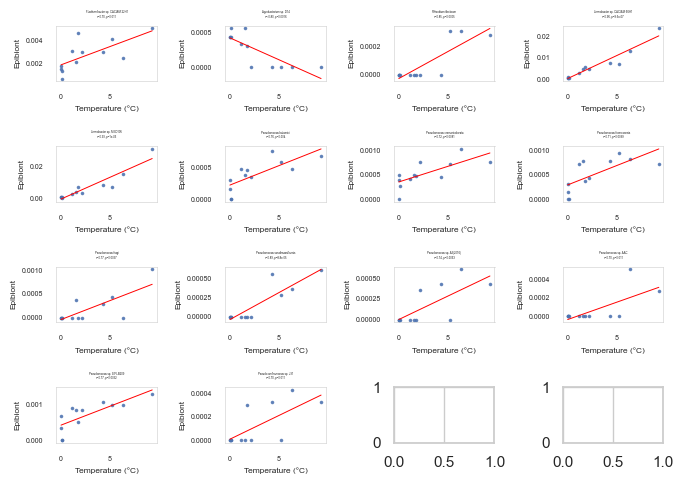

In [75]:
""" plot 
correlation b/w microcystis with epibiotic bacteria before 11/3/2019
"""
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. Load taxon abundance
df =pd.read_csv('kaiju_eqR4m_totalNum_species.tsv', sep='\t', index_col=0)
# only 4 timepoints × 3 replicates
df = df.iloc[:, :12]  # first 4 timepoints × 3 replicates
## plots epibiotic bacteria correlation with temperature
# genera = ['Limnobacter', 'Variovorax', 'Bosea', 'Pseudoxanthomonas', 'Rhizobium', 'Agrobacterium', 'Xanthomonadaceae', 
#           'Brevundimonas', 'Comamonadaceae', 'Phyllobacteriaceae', 'Pseudomonas', 'Sphingopyxis', 'Flavobacterium', 'Hyphomonas',
#           'Flavihumibacter']
m3= ['Microcystis aeruginosa', 'Microcystis wesenbergii2', 'Microcystis flos aquae']
mdict = {'Microcystis aeruginosa': ['Limnobacter', 'Variovorax', 'Bosea', 'Pseudoxanthomonas', 'Rhizobium','Agrobacterium', 'Xanthomonadaceae', 'Brevundimonas'],
         'Microcystis wesenbergii2':['Flavobacterium', 'Limnobacter', 'Hyphomonas', 'Pseudoxanthomonas', 'Bosea', 'Rhizobium', 'Agrobacterium', 'Pseudomonas', 'Flavihumibacter'],
         'Microcystis flos aquae': ['Limnobacter', 'Comamonadaceae', 'Phyllobacteriaceae', 'Pseudoxanthomonas', 'Rhizobium', 'Agrobacterium', 'Pseudomonas', 'Sphingopyxis', 'Brevundimonas']}
df_mar = df[df.index.str.contains(m3[1])]
print(df_mar.shape)
genera = mdict[m3[1]]
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(7, 5))
axes = axes.flatten()
highcorr_dict = {}
plot_idx = 0
for i in range(df.shape[0]):
    indx_str = df.index[i]
    taxonAB = df.iloc[i]
    if not any(species in df.index[i] for species in genera):
        continue
    if np.all(taxonAB.values == taxonAB.values[0]):
        continue
    #print(df_mar.values.flatten())
    #print(taxonAB.values)
    corr_coef, p_value = pearsonr(df_mar.values.flatten(), taxonAB.values)
    if abs(corr_coef) > 0.7 and p_value < 0.05:
        parts = df.index[i].split(';')
        taxon_name = f"{parts[-2]}"
        ax = axes[plot_idx]
        microcystis_abundance = df_mar.iloc[0].values  # or use .loc[...] for the exact species
        sns.regplot(x=microcystis_abundance, y=taxonAB.values, ci=None, line_kws={"color": "red", "linewidth":0.7}, scatter_kws={"s": 2.5}, ax=ax)
        ax.grid(False)
        ax.set_title(f"{taxon_name}\nr={corr_coef:.2f}, p={p_value:.2g}", fontsize=2)
        ax.set_xlabel("Temperature (°C)", fontsize=6)
        ax.tick_params(axis='x', labelsize=5)
        ax.set_ylabel("Epibiont", fontsize=6)
        ax.tick_params(axis='y', labelsize=5)
        ax.tick_params(axis='both', width=0.3)  # thinner ticks
        for spine in ax.spines.values():
            spine.set_linewidth(0.4)

        plot_idx += 1

plt.tight_layout()
#plt.savefig('Mflosaquae-epibiont_corr_w-4temperature_plots.pdf', bbox_inches='tight')
plt.show()



Early-peaking rows: 51
Late-peaking rows: 45


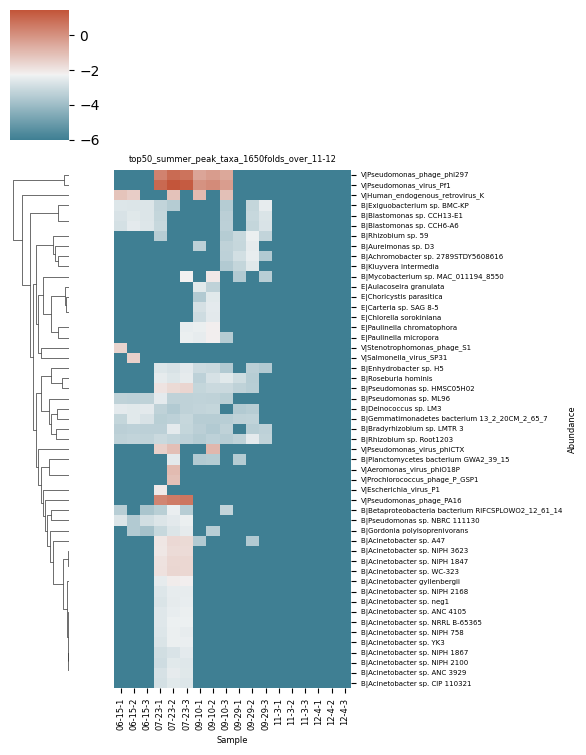

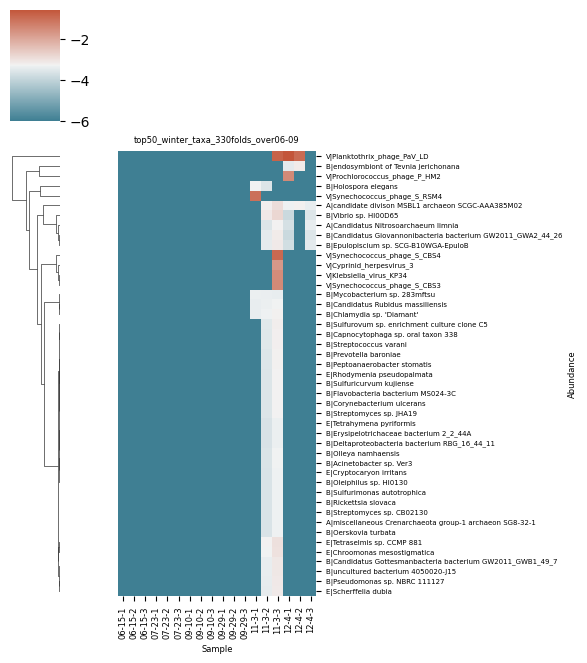

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ----- Load your data -----
df = pd.read_csv('kaiju_eqR4m_totalNum_species.tsv', sep='\t', index_col=0)
df = df[~df.index.str.contains('Cyanobacteria')]

# ----- Define replicate groups -----
tp_0615 = ['mG19_06-15-1', 'mG19_06-15-2', 'mG19_06-15-3']
tp_0723 = ['mG19_07-23-1', 'mG19_07-23-2', 'mG19_07-23-3']
tp_0910 = ['mG19_09-10-1', 'mG19_09-10-2', 'mG19_09-10-3']
tp_0929 = ['mG19_09-29-1', 'mG19_09-29-2', 'mG19_09-29-3']
tp_1103 = ['mG19_11-3-1', 'mG19_11-3-2', 'mG19_11-3-3']
tp_1204 = ['mG19_12-4-1', 'mG19_12-4-2', 'mG19_12-4-3']

early_tp = tp_0615 + tp_0723 + tp_0910 + tp_0929
late_tp = tp_1103 + tp_1204
all_cols = early_tp + late_tp

# ----- Avoid division by zero -----
epsilon = 1e-6
df += epsilon

# ----- Early-peaking condition -----
early_vals = df[early_tp]
late_vals = df[late_tp]

early_peaking = early_vals.max(axis=1) >= 2500 * late_vals.max(axis=1)
late_peaking = late_vals.max(axis=1) >= 450 * early_vals.max(axis=1)

# ----- Subset data -----
early_df = df.loc[early_peaking, all_cols]
early_df.columns = early_df.columns.str.replace('mG19_', '').astype(str)
late_df = df.loc[late_peaking, all_cols]
late_df.columns = late_df.columns.str.replace('mG19_', '').astype(str)

# ----- Log-transform for visualization -----
def log_norm(x): return np.log10(x)

# ----- Custom y-label formatter -----
def format_ylabels(index_series):
    ylabels = []
    for taxon in index_series:
        parts = taxon.split(';')
        if len(parts) >= 2:
            first_word = parts[0].strip()
            first_letter = first_word[0].upper() if first_word else '?'
            second_last_part = parts[-2].strip()
            ylabels.append(f"{first_letter}|{second_last_part}")
        else:
            ylabels.append(taxon)
    return ylabels


# ----- Plotting -----
def plot_heatmap(data, title):
    # Prepare labels
    ylabels = format_ylabels(data.index)

    # Log-transform the data
    log_data = log_norm(data)

    # Create clustermap with row clustering only
    cg = sns.clustermap(
        log_data,
        cmap=sns.diverging_palette(220, 20, as_cmap=True),
        row_cluster=True,
        col_cluster=False,
        figsize=(6, max(1, len(data) * 0.15)),
        yticklabels=ylabels,
        xticklabels=True
    )

    cg.ax_heatmap.set_title(title, fontsize=6)
    cg.ax_heatmap.set_xlabel("Sample", fontsize=6)
    cg.ax_heatmap.set_ylabel("Abundance", fontsize=6)
    cg.ax_heatmap.tick_params(axis='y', labelsize=5)
    cg.ax_heatmap.tick_params(axis='x', labelsize=6)
    plt.tight_layout()
    cg.savefig(f'{title}_heatmap.pdf', bbox_inches='tight')
    plt.show()

# ----- Heatmaps -----
print(f"Early-peaking rows: {early_df.shape[0]}")
print(f"Late-peaking rows: {late_df.shape[0]}")

plot_heatmap(early_df, "top50_summer_peak_taxa_1650folds_over_11-12")
plot_heatmap(late_df, "top50_winter_taxa_330folds_over06-09")


Early-peaking rows: 51
Late-peaking rows: 45


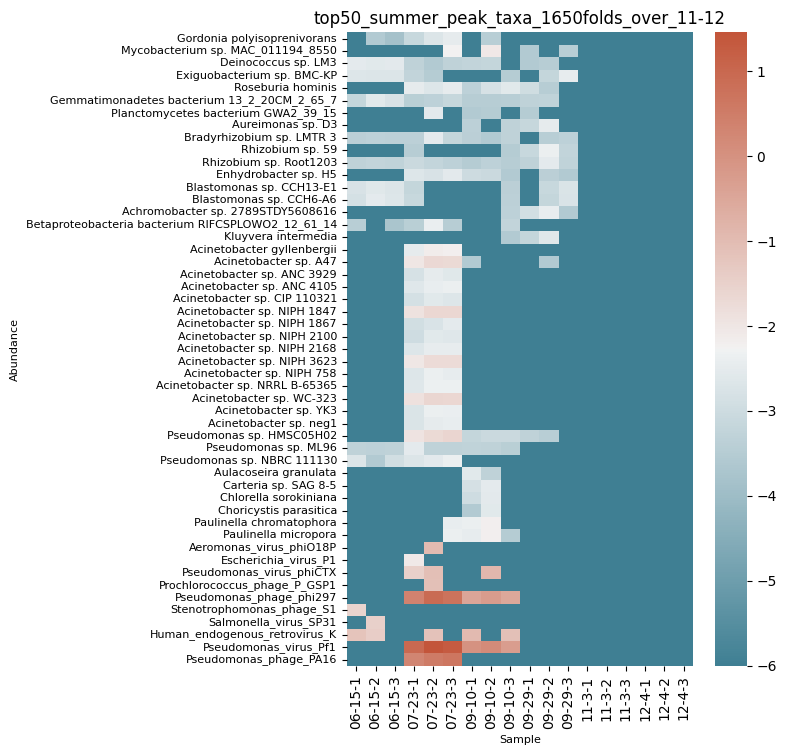

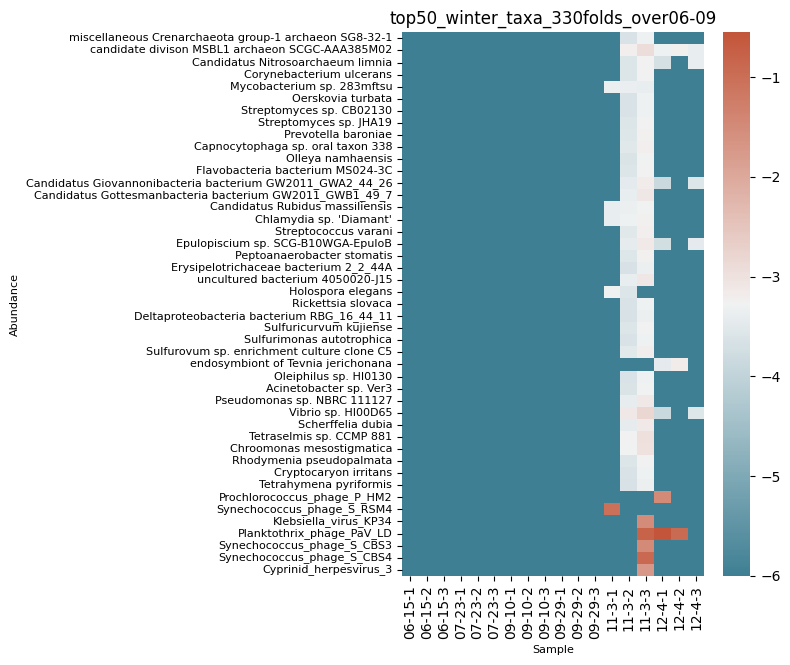

In [ ]:
""" identify and plot summer peak and winter peak taxa"""
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ----- Load your data -----
df =pd.read_csv('kaiju_eqR4m_totalNum_species.tsv', sep='\t', index_col=0)
df = df[~df.index.str.contains('Cyanobacteria')]


# ----- Define replicate groups -----
tp_0615 = ['mG19_06-15-1', 'mG19_06-15-2', 'mG19_06-15-3']
tp_0723 = ['mG19_07-23-1', 'mG19_07-23-2', 'mG19_07-23-3']
tp_0910 = ['mG19_09-10-1', 'mG19_09-10-2', 'mG19_09-10-3']
tp_0929 = ['mG19_09-29-1', 'mG19_09-29-2', 'mG19_09-29-3']
tp_1103 = ['mG19_11-3-1', 'mG19_11-3-2', 'mG19_11-3-3']
tp_1204 = ['mG19_12-4-1', 'mG19_12-4-2', 'mG19_12-4-3']

early_tp = tp_0615 + tp_0723 + tp_0910 + tp_0929
late_tp = tp_1103 + tp_1204
all_cols = early_tp + late_tp

# ----- Avoid division by zero -----
epsilon = 1e-6
df += epsilon

# ----- Early-peaking condition -----
early_vals = df[early_tp]
late_vals = df[late_tp]

# any early val ≥ 5× max late val
early_peaking = early_vals.max(axis=1) >= 2500 * late_vals.max(axis=1)

# ----- Late-peaking condition -----
# any late val ≥ 2× max early val
late_peaking = late_vals.max(axis=1) >= 450 * early_vals.max(axis=1)

# ----- Subset data -----
early_df = df.loc[early_peaking, all_cols]
early_df.columns = early_df.columns.str.replace('mG19_', '').astype(str)
late_df = df.loc[late_peaking, all_cols]
late_df.columns = late_df.columns.str.replace('mG19_', '').astype(str)


# ----- Log-transform for visualization -----
def log_norm(x): return np.log10(x)

# ----- Plotting -----
def plot_heatmap(data, title):
    plt.figure(figsize=(8, max(1, len(data) * 0.15)))
    # Extract second-to-last part from index for yticklabels
    if data.shape[0] > 0 and isinstance(data.index[0], str) and ';' in data.index[0]:
        ylabels = data.index.str.split(';').str[-2]
    else:
        ylabels = data.index
    sns.heatmap(
        log_norm(data),
        cmap=sns.diverging_palette(220, 20, as_cmap=True),
        xticklabels=True,
        yticklabels=ylabels
    )
    plt.yticks(fontsize=8)  # Set yticklabel font size
    plt.title(title)
    plt.ylabel("Abundance", fontsize=8)
    plt.xlabel("Sample", fontsize=8)
    plt.tight_layout()
    #plt.savefig(f'{title}_heatmap.pdf', bbox_inches='tight')
    plt.show()

# ----- Heatmaps -----
print(f"Early-peaking rows: {early_df.shape[0]}")
print(f"Late-peaking rows: {late_df.shape[0]}")

plot_heatmap(early_df, "top50_summer_peak_taxa_1650folds_over_11-12")
plot_heatmap(late_df, "top50_winter_taxa_330folds_over06-09")


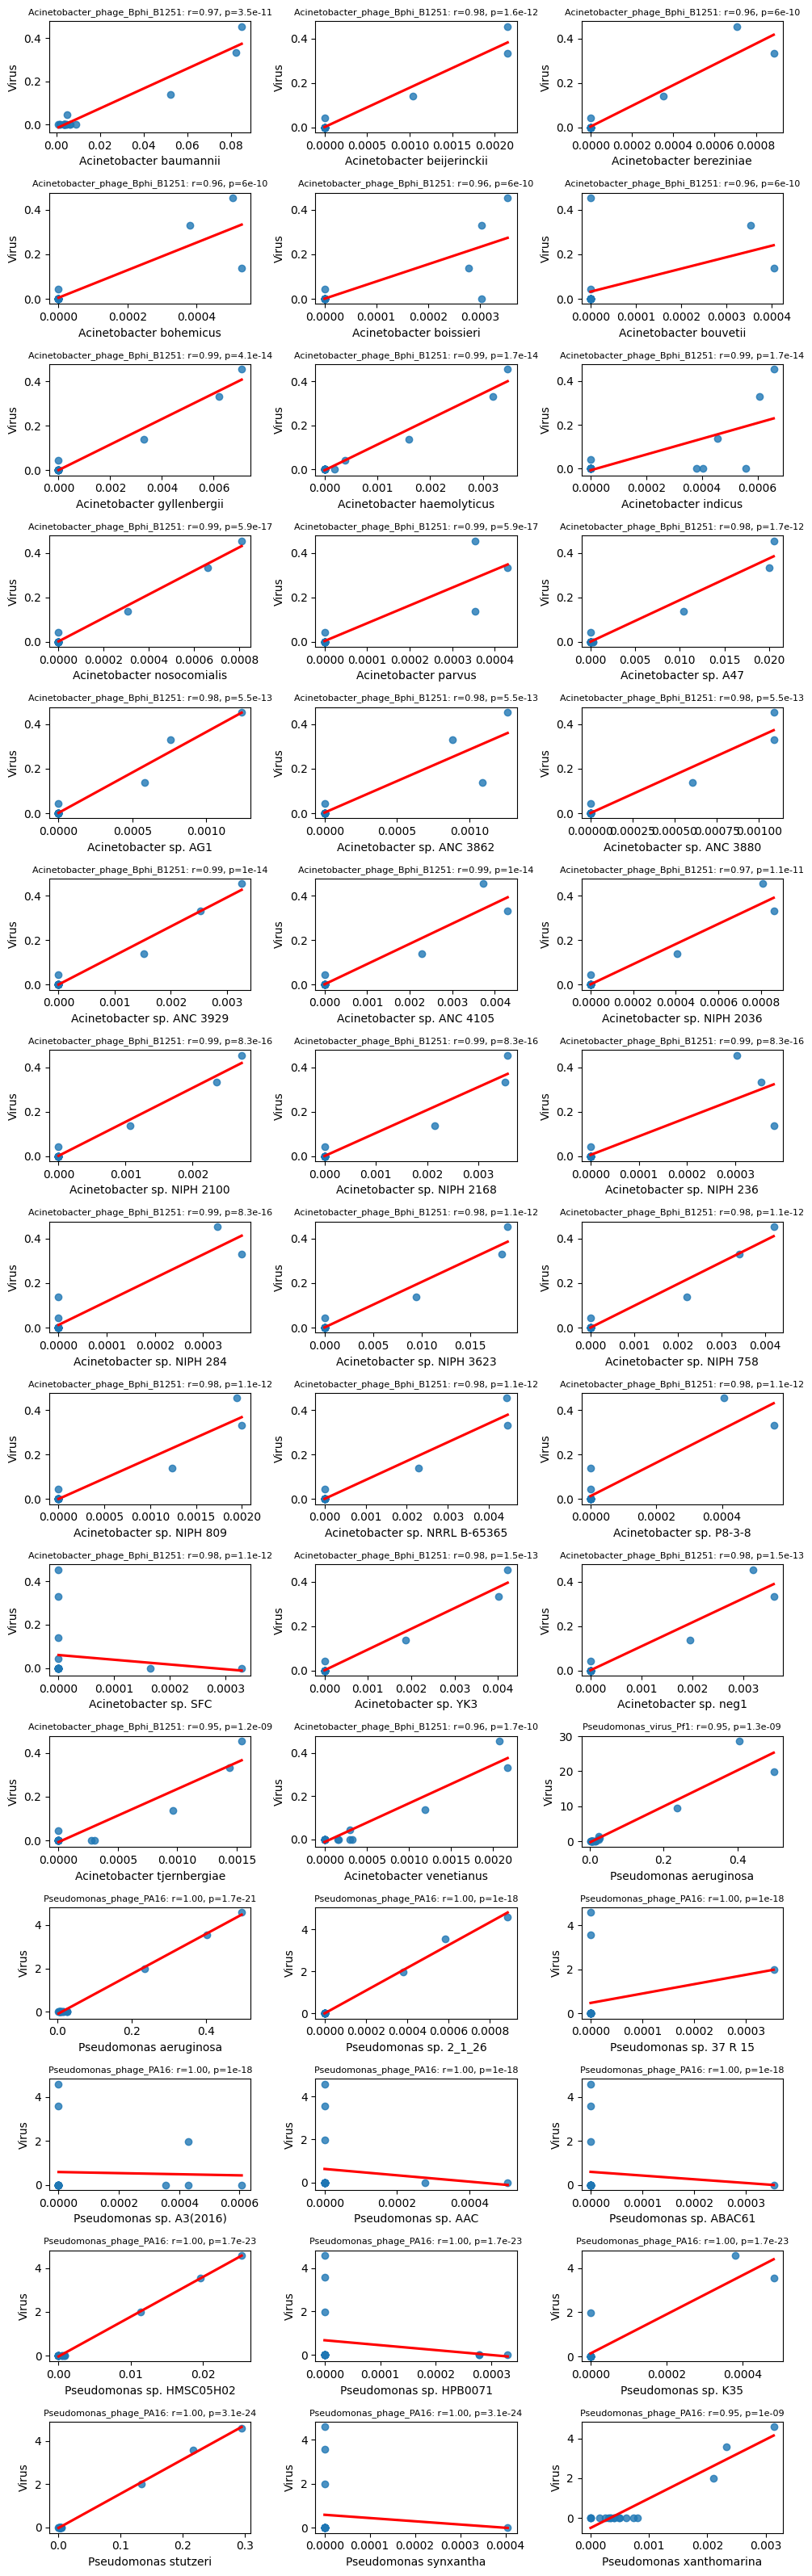

In [76]:

""" plot corr b/w bacteria and viruses """
import pandas as pd
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from scipy.stats import spearmanr

def has_vertical_clusters(x, threshold=3):
    x_counts = Counter(x)
    vertical_points = sum(1 for count in x_counts.values() if count >= threshold)
    return vertical_points > 0

def has_three_groups(x, margin=0.1):
    x = np.array(x)
    x_min, x_max = np.min(x), np.max(x)
    if x_min == x_max:
        return False  # no variation
    low_threshold = x_min * (1 + 1)
    high_threshold = x_max * (1 - 0.5)
    high_group = x >= high_threshold
    low_group = x <= low_threshold
    mid_group = (x > low_threshold) & (x < high_threshold)
    return high_group.sum() > 0 and low_group.sum() > 0 and mid_group.sum() > 0

# ----- Load your data -----
df =pd.read_csv('kaiju_eqR4m_totalNum_species.tsv', sep='\t', index_col=0)
#df = df.iloc[:, :12]  # first 4 timepoints × 3 replicates
#vdf = df[df.index.str.startswith('Viruses')].copy()
vdf = df[(df.index.str.startswith('Viruses')) &(~df.index.str.contains('Microcystis'))].copy()
df = df[~df.index.str.startswith('Viruses')]

fig, axes = plt.subplots(nrows=15, ncols=3, figsize=(10,32))
axes = axes.flatten()
highcorr_dict = {}
plot_idx = 0

for virus in vdf.index:
    vrow = vdf.loc[virus]
    vval = vrow.values
    v_name = virus.split(';')[-2]
    bac_name = v_name.split('_')[0]
    bdf = df[df.index.str.contains(bac_name)]
    # Align columns to vrow (virus) columns to ensure same order and length
    for bname in bdf.index:
        bval = bdf.loc[bname].values
        bs_name = bname.split(';')[-2]
        # Now bval and vval are guaranteed to have the same length/order
        if has_three_groups(bval) and has_three_groups(vval):
            corr_coef, p_value = pearsonr(bval, vval)
        if abs(corr_coef) > 0.95 and p_value < 0.02:
            ax = axes[plot_idx]
            sns.regplot(x=bval, y=vval, ci=None, line_kws={"color": "red"}, ax=ax)
            ax.set_title(f"{v_name}: r={corr_coef:.2f}, p={p_value:.2g}", fontsize=8)
            ax.set_xlabel(bs_name)
            ax.set_ylabel("Virus")
            plot_idx += 1

plt.tight_layout()
plt.savefig('bacteria_virus_corr_w-6temperature_plots.pdf', bbox_inches='tight')
plt.show()

